# 🛠️ Feature Engineering & Selection — Better Inputs Beat Fancier Models

> **What you'll learn:** how to turn raw tables into features a model can use: scaling and which models need it, log / Box-Cox / Yeo-Johnson / quantile transforms, binning, splines and interactions, one-hot, ordinal, hashing and **target encoding** (and its leak), imputation and informative missingness, date and "text-lite" features, group aggregates without leakage, and feature selection (filter, wrapper, embedded, permutation) done **inside** cross-validation. You will build a cross-fitted target encoder and mutual information from scratch, match scikit-learn exactly, and run a full feature-engineering ablation on real house prices.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Anomaly Detection](15_Anomaly_Detection.ipynb) (previous notebook in the series) · [Scikit-Learn](02_Scikit_Learn.ipynb) (pipelines, `ColumnTransformer`, a first look at `TargetEncoder`, leakage) · [Gradient Boosting](10_Gradient_Boosting.ipynb) (how HistGradientBoosting, LightGBM and CatBoost handle categories and missing values) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · pandas 3.0 · numpy 2.5 · statsmodels 0.15 · mlxtend 0.25 · lightgbm 4.7 · catboost 1.2 |
| **Interview relevance** | ⭐⭐⭐ High — "how would you encode a feature with 10,000 categories?", target-encoding leakage, scaling for which models, missing values, feature selection inside CV, multicollinearity, "walk me through your feature pipeline" |

## 🤔 What Is Feature Engineering?

A model never sees a "house". It sees a row of numbers. **Feature engineering** is everything you do to turn raw data into columns that make the pattern easy to learn:

- **Transform** a column so its shape suits the model (log of a price, scaling to similar ranges).
- **Encode** things that aren't numbers (neighbourhood names, dates, text) as numbers.
- **Create** new columns from domain knowledge (total square feet = basement + 1st floor + 2nd floor).
- **Fill** missing values, and sometimes record *that* they were missing.

**Feature selection** is the opposite move: removing columns that add noise, cost or instability.

**Analogy:** a chef's *mise en place*. The same recipe (model) turns out far better when the vegetables are washed, peeled and chopped to the right size (features). A great chef with unprepared ingredients loses to a decent chef with a perfect prep station.

```
raw table ──► clean & encode ──► transform ──► create ──► select ──► model
  (strings, NaN,        (one-hot,        (log,      (ratios,    (drop noise,
   skewed numbers)       target enc.)     splines)    ages)       inside CV!)
```

**The one rule:** anything that *learns from data* (a mean, a category list, a selected feature set) must be learned **from training rows only** — inside a `Pipeline`, so cross-validation refits it in every fold.

## 🎯 Why It Matters

- **On tabular data, features usually move the needle more than swapping models.** Kaggle winners and industry teams spend most of their time here. In Section 1 the *same* Ridge model gets almost 20% lower error on real house prices from engineered features alone.
- **Leakage hides in feature code.** Target encoding, "top-k" selection and group averages computed on the full dataset make offline scores look great and production scores collapse. You will measure these leaks with real numbers.
- **Production pipelines are feature pipelines.** Unknown categories, new missing-value patterns and dtype changes break models in production. `ColumnTransformer`, `handle_unknown` and custom transformers are daily tools for ML engineers.
- **In interviews** this is asked constantly: *"How do you encode a high-cardinality categorical?"*, *"Which models need scaling?"*, *"How do you handle missing values?"*, *"You selected features and got 95% CV accuracy — what could be wrong?"*, *"What is multicollinearity and does it hurt predictions?"*.

## 🃏 Algorithm Card

This notebook teaches *techniques*, not one algorithm, so the card compares the main technique families side by side.

| | Scaling & power transforms | Binning, splines & interactions | One-hot / ordinal / hashing | Target encoding | Imputation (+ indicators) | Feature selection |
|---|---|---|---|---|---|---|
| **Learning type** | Unsupervised preprocessing; applies to any model | Unsupervised; mainly for linear / distance models | Unsupervised; any supervised model | **Supervised** (uses the label); any supervised model | Unsupervised (iterative uses other features) | Filter: unsupervised or supervised; wrapper/embedded: supervised |
| **Tasks** | Regression, classification, clustering | Regression, classification | Any task with categorical inputs | Regression, binary, multiclass | Any task with missing values | Any supervised task |
| **Model / objective** | Standard: $(x-\mu)/\sigma$; MinMax: $(x-\min)/(\max-\min)$; Robust: $(x-\text{median})/\text{IQR}$; Box-Cox / Yeo-Johnson pick λ by maximum likelihood of normality | Bins: piecewise constant; B-splines: smooth piecewise polynomials; interactions: products $x_i x_j$ | One column per category (one-hot), an integer per category (ordinal), or a hash bucket per category | Shrunk category mean: $\lambda_c \bar y_c + (1-\lambda_c)\bar y$, **cross-fitted** on training data | Fill with a statistic (mean/median/mode), neighbours' values (KNN), or a regression on other features (iterative) | Filter: score each feature (variance, correlation, MI, χ²); wrapper: search subsets by CV score; embedded: L1 / tree importance |
| **Key hyperparameters (typical ranges)** | `method` (box-cox needs > 0), `n_quantiles` (≤ rows), `output_distribution` | `n_bins` 4–20, `n_knots` 4–12, `degree` 2–3, `extrapolation="periodic"` for cycles | `min_frequency` (5–50), `max_categories`, `handle_unknown`, `n_features` for hashing ($2^{16}$–$2^{22}$) | `smooth` ("auto" or 1–100), `cv` (5) | `strategy`, `add_indicator`, `n_neighbors` (5–10), `max_iter` (10) | k / percentile, `step`, `cv`, L1 strength `C` / `alpha`, `n_features_to_select` |
| **Needs feature scaling?** | It *is* the scaling | Splines/polynomials: scale or bound first | No | Output is on the target scale; scale for linear models | KNN imputer: yes (distances) | L1 and RFE with linear models: yes; tree-based: no |
| **Handles missing values / categoricals?** | Scalers and power/quantile transformers ignore NaN in `fit` and keep it; numeric only | Spline: `handle_missing` option; numeric only | NaN becomes its own category; categorical only | NaN becomes its own category; unseen → global mean | That's its job; numeric (Simple also works on categories) | Most selectors need complete numeric input |
| **Training & prediction complexity** | O(n·d) | O(n·d·bins) memory; polynomials O(d²) columns | O(n·d); one-hot width = #categories; hashing fixed width | O(n·d·k) for k folds | Simple O(n·d); KNN O(n²·d); iterative O(iters·d·model) | Filter O(n·d); RFE O(d/step · fit); SFS O(d·k · CV fits) — expensive |
| **Interpretability** | High (monotone transforms) | Medium (many basis columns) | High for one-hot/ordinal; low for hashing (collisions) | Medium ("average target for this category") | High; indicators are explicit | High: you keep named columns |
| **Strengths** | Essential for distance, kernel, linear, neural models; tames outliers and skew | Lets linear models bend; captures cycles and interactions | Safe, simple; hashing handles unbounded vocabularies | One compact column even for 100k categories; strong with boosting | Keeps rows; indicators capture "missing means something" | Faster, cheaper, more stable models; removes noise |
| **Weaknesses** | Useless for trees; Box-Cox needs positive data | Feature explosion, overfitting, extrapolation issues | One-hot explodes with high cardinality; ordinal imposes a fake order | **Leaks the label** unless cross-fitted; rare categories noisy | Can hide real signal or bias variance; iterative is experimental | Selection outside CV is badly optimistic; unstable with correlated features |
| **Use it when** | Linear / SVM / KNN / neural models, or skewed targets | A linear model misses a curve, a cycle or an interaction you know exists | Low/medium cardinality (≤ ~50 levels) → one-hot; true order → ordinal; streaming vocab → hashing | High-cardinality categoricals (IDs, ZIP codes, product IDs) | Data has NaN and the model can't take them, or missingness is informative | Many features, few rows, cost/latency limits, or interpretability needs |
| **Avoid it when** | Tree ensembles (no effect) | Tree ensembles already capture it; tiny data | Thousands of levels with a dense linear model (use hashing / target encoding) | Very small data or when a native categorical booster (CatBoost) is available | HistGradientBoosting / LightGBM / XGBoost (native NaN support) unless you need indicators | Strong regularized model already handles it and you don't need fewer columns |
| **Best libraries** | scikit-learn (`StandardScaler`, `RobustScaler`, `PowerTransformer`, `QuantileTransformer`) | scikit-learn (`KBinsDiscretizer`, `SplineTransformer`, `PolynomialFeatures`) | scikit-learn (`OneHotEncoder`, `OrdinalEncoder`, `FeatureHasher`); native: LightGBM, CatBoost, HistGradientBoosting (≤ 255 levels) | scikit-learn `TargetEncoder`; CatBoost's ordered target statistics | scikit-learn (`SimpleImputer`, `KNNImputer`, `IterativeImputer`) | scikit-learn (`SelectKBest`, `RFECV`, `SequentialFeatureSelector`, `SelectFromModel`, `permutation_importance`), mlxtend SFS, statsmodels VIF |

## ✅ By the End You Can

- [ ] Choose scaling, power/quantile transforms, bins, splines and interactions for a model, and prove the choice with cross-validation
- [ ] Encode categoricals with one-hot, ordinal, hashing and target encoding, and explain (and measure) the target-encoding leak
- [ ] Impute missing values with simple, KNN and iterative imputers, and test whether missingness itself is informative
- [ ] Build date, "text-lite", count and group-aggregate features without leaking information across folds
- [ ] Select features with filter, wrapper and embedded methods **inside** a CV pipeline, and diagnose multicollinearity with VIF
- [ ] Implement a cross-fitted target encoder and mutual information from scratch, matching scikit-learn exactly

## 📋 Table of Contents

1. [Features Matter More Than the Model](#1.-Features-Matter-More-Than-the-Model-🟢)
2. [Scaling: Which Models Care?](#2.-Scaling:-Which-Models-Care?-🟢)
3. [Skewed Numbers: Log, Box-Cox, Yeo-Johnson and Quantiles](#3.-Skewed-Numbers:-Log,-Box-Cox,-Yeo-Johnson-and-Quantiles-🟢)
4. [Binning, Splines and Interactions](#4.-Binning,-Splines-and-Interactions-🟡)
5. [Categorical Encoding: One-Hot, Ordinal and Hashing](#5.-Categorical-Encoding:-One-Hot,-Ordinal-and-Hashing-🟢)
6. [Target Encoding and Its Leak](#6.-Target-Encoding-and-Its-Leak-🔴)
7. [Missing Values: Imputers and Informative Missingness](#7.-Missing-Values:-Imputers-and-Informative-Missingness-🟡)
8. [Dates, Text-Lite Features and Group Aggregates](#8.-Dates,-Text-Lite-Features-and-Group-Aggregates-🟡)
9. [Filter Selection: Variance, Correlation, Mutual Information, Chi-Squared](#9.-Filter-Selection:-Variance,-Correlation,-Mutual-Information,-Chi-Squared-🟡)
10. [Wrapper and Embedded Selection](#10.-Wrapper-and-Embedded-Selection-🟡)
11. [Selection Must Live Inside Cross-Validation](#11.-Selection-Must-Live-Inside-Cross-Validation-🔴)
12. [Correlated Features and Multicollinearity](#12.-Correlated-Features-and-Multicollinearity-🟡)
13. [Production Pipelines and Custom Transformers](#13.-Production-Pipelines-and-Custom-Transformers-🟡)
- [🃏 Algorithm Card](#🃏-Algorithm-Card) · [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Ames-Feature-Engineering-Ablation) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

**Data (all real, downloaded once from OpenML into `_outputs/sklearn_data/`, ~6 MB in total):**
- **Ames House Prices** (OpenML 42165): 1,460 home sales in Ames, Iowa with 79 mixed-type columns and lots of missing values. We lock away a 20% test set for the mini project.
- **Bike Sharing Demand** (OpenML 42712): 17,379 hourly rental counts with weather and calendar columns, in time order.
- **Titanic** (OpenML 40945): 1,309 passengers with names, tickets, cabins and missing ages.
- **Adult census income** (OpenML 1590): 48,842 people, income above/below $50K.
- **Amazon Employee Access** (OpenML 4135): 32,769 access requests described by 9 ID-like categorical columns with up to 7,518 levels — the classic high-cardinality dataset.
- **Breast cancer** (bundled with scikit-learn): 30 numeric features, used for fast selection experiments.

In [1]:
# %pip install -q "scikit-learn>=1.6" "pandas>=2.2" "statsmodels>=0.14" "mlxtend>=0.23" "lightgbm>=4" "catboost>=1.2" matplotlib

import sys
import time
import warnings
from pathlib import Path

import catboost
import lightgbm
import matplotlib.pyplot as plt
import mlxtend
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
from mlxtend.feature_selection import SequentialFeatureSelector as MlxtendSFS
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor, make_column_selector
from sklearn.datasets import fetch_openml, load_breast_cancer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  — IterativeImputer is still experimental
from sklearn.feature_extraction import FeatureHasher
from sklearn.feature_selection import (
    RFECV,
    SelectFromModel,
    SelectKBest,
    SequentialFeatureSelector,
    VarianceThreshold,
    chi2,
    f_classif,
    mutual_info_classif,
    mutual_info_regression,
)
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegression, RidgeCV
from sklearn.metrics import mutual_info_score, roc_auc_score, root_mean_squared_error
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    TimeSeriesSplit,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PolynomialFeatures,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    SplineTransformer,
    StandardScaler,
    TargetEncoder,
)
from sklearn.utils.estimator_checks import check_estimator
from sklearn.utils.validation import check_is_fitted, validate_data
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"scipy {scipy.__version__} | statsmodels {statsmodels.__version__} | mlxtend {mlxtend.__version__} | "
      f"lightgbm {lightgbm.__version__} | catboost {catboost.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
DATA_HOME = OUTPUT_DIR / "sklearn_data"    # scikit-learn / OpenML download cache
DATA_HOME.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str, dict, set)) or (
            isinstance(expected, (list, tuple)) and expected and isinstance(expected[0], str)):
        ok = (list(got) == list(expected)) if isinstance(expected, (list, tuple)) else got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | scikit-learn 1.9.1 | pandas 3.0.5 | numpy 2.5.3 | scipy 1.18.1 | statsmodels 0.15.0 | mlxtend 0.25.0 | lightgbm 4.7.0 | catboost 1.2.10


In [2]:
def openml(**kwargs):
    return fetch_openml(as_frame=True, data_home=DATA_HOME, **kwargs)


ames = openml(data_id=42165).frame.drop(columns="Id")
ames_train, ames_test = train_test_split(ames, test_size=0.2, random_state=SEED)   # the test part is only used at the end of the mini project
ames_X, ames_y = ames_train.drop(columns="SalePrice"), ames_train["SalePrice"]

bike = openml(name="Bike_Sharing_Demand", version=2).frame
titanic = openml(name="titanic", version=1).frame
adult = openml(name="adult", version=2)
amazon = openml(data_id=4135)

print(f"Ames: {ames.shape} → train {ames_train.shape[0]:,} / locked test {ames_test.shape[0]:,} | "
      f"{ames_X.select_dtypes('number').shape[1]} numeric + {ames_X.select_dtypes(exclude='number').shape[1]} text columns | "
      f"{ames_X.isna().any().sum()} columns have missing values")
print(f"Bike sharing: {bike.shape} (hourly, time-ordered) | Titanic: {titanic.shape} | Adult: {adult.frame.shape} | "
      f"Amazon access: {amazon.frame.shape}, max levels per column {amazon.data.nunique().max():,}")

Ames: (1460, 80) → train 1,168 / locked test 292 | 36 numeric + 43 text columns | 19 columns have missing values
Bike sharing: (17379, 13) (hourly, time-ordered) | Titanic: (1309, 14) | Adult: (48842, 15) | Amazon access: (32769, 10), max levels per column 7,518


## 1. Features Matter More Than the Model 🟢

Let's measure the claim before believing it. Same model (**Ridge regression**, a regularized linear model — see [Linear Regression](03_Linear_Regression.ipynb)), same 5 cross-validation folds on the Ames training split, two different inputs:

1. **Raw:** the 36 numeric columns as they come (missing values filled with the median, then standardized). The 43 text columns are simply dropped, as a beginner might do.
2. **Engineered:** what a thoughtful analyst would do in an afternoon:
   - **new domain features:** total square feet, house age at sale, years since remodel, total bathrooms, total porch area;
   - **log** of the skewed area columns and of the **target** (prices are multiplicative: a nice kitchen adds a *percentage*, not a fixed dollar amount);
   - **ordinal** codes for the quality ratings (`Po < Fa < TA < Gd < Ex`) where missing means "no garage/basement/pool";
   - **one-hot** codes for nominal text columns such as `Neighborhood`, with rare levels grouped.

As a reference we add a model that needs much less preparation: **HistGradientBoosting** on the raw columns (text columns turned into integer codes).

The error is **RMSE in dollars** on the held-out fold, averaged over 5 folds (lower is better).

In [3]:
QUALITY_COLS = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu",
                "GarageQual", "GarageCond", "PoolQC"]
QUALITY_ORDER = ["None", "Po", "Fa", "TA", "Gd", "Ex"]          # NaN in these columns means "no basement / garage / pool"
AREA_COLS = ["LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF",
             "2ndFlrSF", "LowQualFinSF", "GrLivArea", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
             "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal", "TotalSF", "TotalPorchSF"]   # chosen by meaning, not by peeking


def add_ames_features(df):
    """Domain features any appraiser would compute. Row-wise only: nothing is learned from other rows, so no leakage."""
    return df.assign(
        TotalSF=df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"],
        HouseAge=df["YrSold"] - df["YearBuilt"],
        YearsSinceRemodel=df["YrSold"] - df["YearRemodAdd"],
        TotalBath=df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"],
        TotalPorchSF=df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"] + df["WoodDeckSF"],
    )


NUM_RAW = ames_X.select_dtypes("number").columns.tolist()
CAT_RAW = ames_X.select_dtypes(exclude="number").columns.tolist()
NUM_ENG = add_ames_features(ames_X).select_dtypes("number").columns.tolist()
SKEWED = [c for c in AREA_COLS if c in NUM_ENG]
OTHER_NUM = [c for c in NUM_ENG if c not in SKEWED]
NOMINAL = [c for c in CAT_RAW if c not in QUALITY_COLS]
ALPHAS = np.logspace(-2, 3, 30)
ames_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)


def log_target(model):
    """Fit on log(price), predict back in dollars."""
    return TransformedTargetRegressor(model, func=np.log, inverse_func=np.exp)


def cv_rmse(model, X, y=None, cv=None):
    y = ames_y if y is None else y
    scores = -cross_val_score(model, X, y, cv=ames_cv if cv is None else cv, scoring="neg_root_mean_squared_error")
    return scores.mean(), scores.std()


def ames_engineered_preprocessor():
    return ColumnTransformer([
        ("skewed", make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                                 StandardScaler()), SKEWED),
        ("numeric", make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), OTHER_NUM),
        ("quality", make_pipeline(SimpleImputer(strategy="constant", fill_value="None"),
                                  OrdinalEncoder(categories=[QUALITY_ORDER] * len(QUALITY_COLS), handle_unknown="use_encoded_value",
                                                 unknown_value=-1), StandardScaler()), QUALITY_COLS),
        ("nominal", make_pipeline(SimpleImputer(strategy="constant", fill_value="None"),
                                  OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False)), NOMINAL),
    ])


raw_prep = ColumnTransformer([("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUM_RAW)])
section1_models = {
    "Ridge · raw numeric columns": make_pipeline(raw_prep, RidgeCV(alphas=ALPHAS)),
    "Ridge · engineered features + log target": log_target(make_pipeline(FunctionTransformer(add_ames_features),
                                                                         ames_engineered_preprocessor(), RidgeCV(alphas=ALPHAS))),
    "HistGradientBoosting · raw columns (reference)": make_pipeline(
        ColumnTransformer([("text", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan,
                                                   encoded_missing_value=np.nan), CAT_RAW)], remainder="passthrough"),
        HistGradientBoostingRegressor(random_state=SEED)),
}
n_inputs = {
    "Ridge · raw numeric columns": raw_prep.fit_transform(ames_X).shape[1],
    "Ridge · engineered features + log target": ames_engineered_preprocessor().fit_transform(add_ames_features(ames_X)).shape[1],
    "HistGradientBoosting · raw columns (reference)": ames_X.shape[1],
}
section1 = pd.DataFrame({name: dict(zip(["CV RMSE ($)", "fold std ($)"], cv_rmse(model, ames_X)), **{"columns into the model": n_inputs[name]})
                         for name, model in section1_models.items()}).T
print(section1.round(0))
raw_rmse = section1.loc["Ridge · raw numeric columns", "CV RMSE ($)"]
eng_rmse = section1.loc["Ridge · engineered features + log target", "CV RMSE ($)"]
hgb_rmse = section1.loc["HistGradientBoosting · raw columns (reference)", "CV RMSE ($)"]
print(f"\nSame Ridge model: engineered features cut the error by ${raw_rmse - eng_rmse:,.0f} ({1 - eng_rmse / raw_rmse:.1%}). "
      f"Gradient boosting on raw columns: ${hgb_rmse:,.0f} — "
      f"{'still better' if hgb_rmse < eng_rmse else 'now matched'}: trees find interactions and thresholds by themselves.")

                                                CV RMSE ($)  fold std ($)  columns into the model
Ridge · raw numeric columns                         37170.0        6996.0                    36.0
Ridge · engineered features + log target            29994.0        8697.0                   225.0
HistGradientBoosting · raw columns (reference)      29075.0        5218.0                    79.0

Same Ridge model: engineered features cut the error by $7,176 (19.3%). Gradient boosting on raw columns: $29,075 — still better: trees find interactions and thresholds by themselves.


Two lessons from real numbers:

- Feature work bought the linear model a large improvement **without changing the algorithm**. Every idea came from understanding the domain (areas add up, prices are multiplicative, quality ratings have an order).
- Tree ensembles need far less of this (no scaling, no log, no one-hot), which is why they are the default for tabular data. They still benefit from *new information* (Section 8 and the mini project), but not from monotone transforms.

### ✍️ Your Turn

Add two domain features to the small `houses` table: `TotalSF` (basement + 1st floor + 2nd floor) and `HouseAge` (year sold − year built). Store `houses_feat[["TotalSF", "HouseAge"]].to_numpy()` in `new_features`.

In [4]:
houses = pd.DataFrame({"TotalBsmtSF": [800, 0], "1stFlrSF": [900, 1200], "2ndFlrSF": [600, 0],
                       "YearBuilt": [1990, 2005], "YrSold": [2008, 2010]})
new_features = None  # TODO: your code here
check("new_features", new_features, [[2300, 18], [1200, 5]],
      hint="houses.assign(TotalSF=houses['TotalBsmtSF'] + houses['1stFlrSF'] + houses['2ndFlrSF'], HouseAge=houses['YrSold'] - houses['YearBuilt'])")

⏳ new_features: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
houses = pd.DataFrame({"TotalBsmtSF": [800, 0], "1stFlrSF": [900, 1200], "2ndFlrSF": [600, 0],
                       "YearBuilt": [1990, 2005], "YrSold": [2008, 2010]})
houses_feat = houses.assign(TotalSF=houses["TotalBsmtSF"] + houses["1stFlrSF"] + houses["2ndFlrSF"],
                            HouseAge=houses["YrSold"] - houses["YearBuilt"])
new_features = houses_feat[["TotalSF", "HouseAge"]].to_numpy()
check("new_features", new_features, [[2300, 18], [1200, 5]])
```

Row-wise features like these use only the row itself, so they can be computed before splitting without leakage. Anything that looks at *other rows* (means, counts, ranks) must be learned inside the pipeline.
</details>

> 💡 **Interview angle:** "How would you improve this model?" — before tuning or switching algorithms, look at the features: domain combinations (totals, ratios, ages), transforms matching how the target behaves (log for multiplicative effects), proper encodings. Show an ablation: same model, same folds, feature groups added one at a time.

## 2. Scaling: Which Models Care? 🟢

Features live on wildly different scales: `LotArea` goes up to 215,245 square feet while `OverallQual` is 1–10.

| Scaler | Formula | Output | Sensitive to outliers? |
|---|---|---|---|
| `StandardScaler` | $(x - \mu) / \sigma$ | mean 0, std 1 | yes (μ and σ move) |
| `MinMaxScaler` | $(x - \min) / (\max - \min)$ | [0, 1] on training data | very (one extreme squashes everyone else) |
| `RobustScaler` | $(x - \text{median}) / \text{IQR}$ | median 0, IQR 1 | no — but outliers stay far away |

**Who cares?**

- **Distance-based** models (KNN, k-means, SVM with RBF kernel): the biggest-number column dominates the distance.
- **Regularized linear models** (Ridge, Lasso, logistic regression): the penalty $\lambda\sum w_j^2$ punishes a coefficient more when its feature has a small scale.
- **Gradient descent** (neural nets): unscaled inputs make optimization slow.
- **Trees and tree ensembles do not care:** a split "`LotArea` < 9,000" works the same after any monotone rescaling.

Let's measure it on the Ames numeric columns.

In [5]:
ames_num = ames_X[NUM_RAW]
scalers = {"no scaling": "passthrough", "StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler(), "RobustScaler": RobustScaler()}
scaling_rows = {}


def fresh(step):
    return step if isinstance(step, str) else clone(step)      # "passthrough" is a string, not an estimator


for name, scaler in scalers.items():
    scaling_rows[name] = {
        "KNN (k=10)": cv_rmse(make_pipeline(SimpleImputer(strategy="median"), fresh(scaler), KNeighborsRegressor(n_neighbors=10)), ames_num)[0],
        "Ridge": cv_rmse(make_pipeline(SimpleImputer(strategy="median"), fresh(scaler), RidgeCV(alphas=ALPHAS)), ames_num)[0],
        "HistGradientBoosting": cv_rmse(make_pipeline(fresh(scaler), HistGradientBoostingRegressor(random_state=SEED)), ames_num)[0],
    }
scaling_table = pd.DataFrame(scaling_rows).T
print("5-fold CV RMSE ($) on 36 numeric Ames columns")
print(scaling_table.round(0))
for model in scaling_table.columns:
    spread = scaling_table[model].max() - scaling_table[model].min()
    print(f"{model:21s}: best {scaling_table[model].idxmin():15s} | spread across scalers ${spread:,.0f}")

5-fold CV RMSE ($) on 36 numeric Ames columns
                KNN (k=10)    Ridge  HistGradientBoosting
no scaling         48018.0  36548.0               30079.0
StandardScaler     37669.0  37170.0               30090.0
MinMaxScaler       39663.0  37297.0               30079.0
RobustScaler       50080.0  36590.0               30079.0
KNN (k=10)           : best StandardScaler  | spread across scalers $12,411
Ridge                : best no scaling      | spread across scalers $749
HistGradientBoosting : best RobustScaler    | spread across scalers $12


KNN changes a lot, HistGradientBoosting doesn't move. Ridge moves less than you might expect because `RidgeCV` re-tunes its penalty strength for each scaling, which partly compensates; the *coefficients* still change, which matters when you interpret them. **Why is `RobustScaler` the worst for KNN here?** Its divisor is the interquartile range (IQR). Many Ames columns are zero for most houses (pool area, porch areas), so their IQR is 0, and scikit-learn then leaves those columns **unscaled** (it can't divide by 0). A single pool of 500 sq ft then dominates the distance.

In [6]:
q1, q3 = ames_num.quantile(0.25), ames_num.quantile(0.75)
zero_iqr = (q3 - q1)[lambda s: s == 0].index.tolist()
robust_scaled = pd.DataFrame(RobustScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(ames_num)), columns=NUM_RAW)
standard_scaled = pd.DataFrame(StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(ames_num)), columns=NUM_RAW)
print(f"{len(zero_iqr)} columns have IQR = 0: {zero_iqr}")
print(pd.DataFrame({"max after RobustScaler": robust_scaled[zero_iqr].max(), "max after StandardScaler": standard_scaled[zero_iqr].max()}).round(1))

9 columns have IQR = 0: ['BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', 'KitchenAbvGr', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']
               max after RobustScaler  max after StandardScaler
BsmtFinSF2                     1127.0                       6.8
LowQualFinSF                    572.0                      11.8
BsmtHalfBath                      2.0                       8.2
KitchenAbvGr                      2.0                       8.7
EnclosedPorch                   552.0                       8.5
3SsnPorch                       508.0                      16.0
ScreenPorch                     480.0                       8.3
PoolArea                        738.0                      17.7
MiscVal                       15500.0                      27.9


### ✍️ Your Turn

Robust-scale `values = [1, 2, 3, 4, 100]` **by hand** (median and IQR with `np.percentile`) and store the result in `robust_by_hand`. The checker compares with `RobustScaler`.

In [7]:
values = np.array([1.0, 2.0, 3.0, 4.0, 100.0])
robust_by_hand = None  # TODO: your code here
check("robust_by_hand", robust_by_hand, RobustScaler().fit_transform(values.reshape(-1, 1)).ravel(),
      hint="(values - np.median(values)) / (np.percentile(values, 75) - np.percentile(values, 25))")

⏳ robust_by_hand: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
values = np.array([1.0, 2.0, 3.0, 4.0, 100.0])
robust_by_hand = (values - np.median(values)) / (np.percentile(values, 75) - np.percentile(values, 25))
check("robust_by_hand", robust_by_hand, RobustScaler().fit_transform(values.reshape(-1, 1)).ravel())
```

Result `[-1, -0.5, 0, 0.5, 48.5]`: the typical values get a sensible scale, and the outlier stays an outlier (48.5) instead of squashing everyone else like `MinMaxScaler` would.
</details>

> 💡 **Interview angle:** "Do I need to scale features for a random forest?" — no: tree splits are invariant to monotone transforms. You do for KNN, SVMs, k-means, PCA, regularized linear models and neural nets. Fit the scaler on training folds only (inside the pipeline), and pick Robust/Quantile when outliers matter — but check zero-IQR columns.

## 3. Skewed Numbers: Log, Box-Cox, Yeo-Johnson and Quantiles 🟢

Areas, incomes and prices are **right-skewed**: most values are modest, a few are huge. A linear model then spends its effort on the few giants, and errors grow with size. Transforms that pull in the long tail:

| Transform | Formula | Works on | Notes |
|---|---|---|---|
| log / `np.log1p` | $\log(1 + x)$ | $x \ge 0$ | simplest; turns multiplicative effects into additive ones |
| **Box-Cox** | $\frac{x^\lambda - 1}{\lambda}$ ($\log x$ when $\lambda = 0$) | $x > 0$ only | λ chosen by maximum likelihood to make the data as normal as possible |
| **Yeo-Johnson** | Box-Cox-like, extended to 0 and negatives | any real $x$ | `PowerTransformer`'s default |
| **Quantile** | rank → uniform or normal quantile | anything | forces the exact shape; destroys distances between extreme values |

`PowerTransformer` learns one λ per column in `fit` (training rows only) and standardizes the result by default.

Skewness (0 = symmetric); Box-Cox is NaN where a column contains zeros
               raw  log1p  Yeo-Johnson  Quantile → normal  Box-Cox
LotArea      11.94  -0.01         0.00               0.00      0.0
GrLivArea     1.42   0.01        -0.00              -0.00     -0.0
MasVnrArea    2.28   0.44         0.37               0.38      NaN
OpenPorchSF   2.33  -0.06        -0.04              -0.16      NaN

learned Box-Cox lambdas: {'LotArea': np.float64(0.003), 'GrLivArea': np.float64(-0.006)}


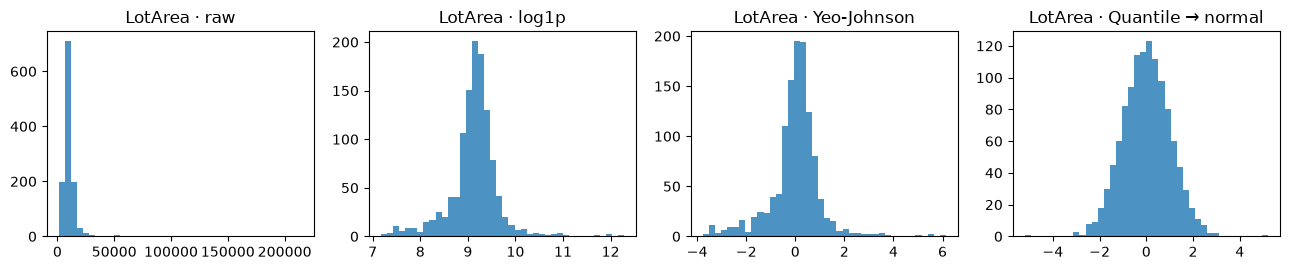

In [8]:
skew_cols = ["LotArea", "GrLivArea", "MasVnrArea", "OpenPorchSF"]
skew_frame = ames_X[skew_cols]
transforms = {
    "raw": lambda d: d.to_numpy(dtype=float),
    "log1p": lambda d: np.log1p(d.to_numpy(dtype=float)),
    "Yeo-Johnson": lambda d: PowerTransformer(method="yeo-johnson").fit_transform(d),
    "Quantile → normal": lambda d: QuantileTransformer(output_distribution="normal", n_quantiles=500, random_state=SEED).fit_transform(d),
}
skew_table = pd.DataFrame({name: stats.skew(f(skew_frame), nan_policy="omit") for name, f in transforms.items()}, index=skew_cols)
positive_only = [c for c in skew_cols if (skew_frame[c].dropna() > 0).all()]
boxcox = PowerTransformer(method="box-cox").fit(skew_frame[positive_only])
skew_table["Box-Cox"] = pd.Series(stats.skew(boxcox.transform(skew_frame[positive_only]), nan_policy="omit"), index=positive_only)
print("Skewness (0 = symmetric); Box-Cox is NaN where a column contains zeros")
print(skew_table.round(2))
print("\nlearned Box-Cox lambdas:", dict(zip(positive_only, boxcox.lambdas_.round(3))))

fig, axes = plt.subplots(1, 4, figsize=(13, 2.8))
for ax, (name, f) in zip(axes, transforms.items()):
    ax.hist(f(ames_X[["LotArea"]]).ravel(), bins=40, color="tab:blue", alpha=0.8)
    ax.set_title(f"LotArea · {name}")
plt.tight_layout()
plt.show()

Does it help a model? Ridge on the numeric columns (median-imputed), log target, with each transform applied to every numeric column inside the pipeline:

In [9]:
power_models = {
    "StandardScaler only": StandardScaler(),
    "log1p on area columns, then scale": ColumnTransformer(
        [("area", make_pipeline(FunctionTransformer(np.log1p), StandardScaler()), [c for c in AREA_COLS if c in NUM_RAW])],
        remainder=StandardScaler()),
    "Yeo-Johnson on all": PowerTransformer(method="yeo-johnson"),
    "Quantile → normal on all": QuantileTransformer(output_distribution="normal", n_quantiles=500, random_state=SEED),
}
power_rmse = pd.Series({name: cv_rmse(log_target(make_pipeline(SimpleImputer(strategy="median").set_output(transform="pandas"),
                                                                tf, RidgeCV(alphas=ALPHAS))), ames_num)[0]
                        for name, tf in power_models.items()}, name="CV RMSE ($)").sort_values()
print(power_rmse.round(0))
print(f"\nbest: {power_rmse.index[0]} — ${power_rmse.iloc[-1] - power_rmse.iloc[0]:,.0f} better than the worst option")

log1p on area columns, then scale    31950.0
Yeo-Johnson on all                   35210.0
Quantile → normal on all             35846.0
StandardScaler only                  47211.0
Name: CV RMSE ($), dtype: float64

best: log1p on area columns, then scale — $15,262 better than the worst option


With a log target, un-transformed giant houses get exponentially over-predicted, so shrinking the skewed inputs matters a lot for a linear model. The exact winner between log, Yeo-Johnson and quantile depends on the data: **measure with CV**, don't assume.

### ✍️ Your Turn

Apply the Box-Cox formula with a **fixed** $\lambda = 0.5$ to `x = [1, e, e²]` by hand and store it in `boxcox_half`. (The checker uses `scipy.stats.boxcox(x, lmbda=0.5)`.)

In [10]:
x_pos = np.array([1.0, np.e, np.e ** 2])
boxcox_half = None  # TODO: your code here
check("boxcox_half", boxcox_half, stats.boxcox(x_pos, lmbda=0.5), hint="(x_pos ** 0.5 - 1) / 0.5")

⏳ boxcox_half: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_pos = np.array([1.0, np.e, np.e ** 2])
boxcox_half = (x_pos ** 0.5 - 1) / 0.5
check("boxcox_half", boxcox_half, stats.boxcox(x_pos, lmbda=0.5))
```

λ = 1 is just a shift, λ = 0.5 is a square-root-like squeeze, λ → 0 becomes the log. Box-Cox searches λ so the transformed column looks as normal as possible.
</details>

> 💡 **Interview angle:** "Log vs Box-Cox vs Yeo-Johnson?" — log is the simple default for positive, multiplicative data; Box-Cox learns the best power but needs strictly positive values; Yeo-Johnson extends it to zeros and negatives. All are monotone, so they matter for linear/distance models and not for trees. If you log the **target**, remember predictions come back as a geometric-mean-like estimate.

## 4. Binning, Splines and Interactions 🟡

A linear model draws straight lines. Bike rentals by **hour** are anything but: two commuter peaks on working days, one afternoon hump at weekends. Ways to let a linear model bend:

- **One-hot per hour:** a separate level per value (24 columns).
- **Binning** (`KBinsDiscretizer`): group values into ranges, one column per bin — coarse steps.
- **Sine/cosine:** place hour on a circle so 23:00 and 00:00 are neighbours (Section 8 explains the geometry).
- **Splines** (`SplineTransformer`): smooth piecewise polynomials joined at *knots*; `extrapolation="periodic"` makes the end of the day join the start.
- **Interactions** (`PolynomialFeatures(interaction_only=True)`): products of features, e.g. hour-spline × working day, so the daily curve can differ between weekdays and weekends.

The data is a time series, so we use `TimeSeriesSplit`: always train on the past and validate on the next 1,000 hours, with a 48-hour gap to avoid near-duplicate neighbours. Metric: mean absolute error (MAE) in rentals per hour.

In [11]:
bike_y = bike["count"]
bike_X = bike.drop(columns="count")
bike_cv = TimeSeriesSplit(n_splits=5, gap=48, max_train_size=10_000, test_size=1_000)
BIKE_CAT = ["season", "holiday", "workingday", "weather"]
BIKE_NUM = ["temp", "feel_temp", "humidity", "windspeed", "year"]
HOUR_KNOTS = np.linspace(0, 24, 13).reshape(-1, 1)          # a knot every 2 hours, wrapping at 24


def sin_cos(X, period):
    values = np.asarray(X, dtype=float)
    return np.hstack([np.sin(2 * np.pi * values / period), np.cos(2 * np.pi * values / period)])


def bike_ridge(hour_encoder):
    return make_pipeline(ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), BIKE_CAT),
        ("num", MinMaxScaler(), BIKE_NUM),
        ("hour", hour_encoder, ["hour"]),
        ("calendar", MinMaxScaler(), ["month", "weekday"]),
    ]), RidgeCV(alphas=ALPHAS))


hour_spline = SplineTransformer(knots=HOUR_KNOTS, degree=3, extrapolation="periodic")
spline_by_workingday = make_pipeline(
    ColumnTransformer([("hour", clone(hour_spline), ["hour"]), ("wd", OneHotEncoder(sparse_output=False), ["workingday"])]),
    PolynomialFeatures(degree=2, interaction_only=True, include_bias=False))
bike_models = {
    "hour as a number": bike_ridge(MinMaxScaler()),
    "hour binned (8 equal-width bins)": bike_ridge(KBinsDiscretizer(n_bins=8, encode="onehot-dense", strategy="uniform")),
    "hour sine/cosine": bike_ridge(FunctionTransformer(sin_cos, kw_args={"period": 24})),
    "hour one-hot (24 levels)": bike_ridge(OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    "hour periodic spline": bike_ridge(clone(hour_spline)),
    "hour spline × working day": make_pipeline(ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), BIKE_CAT),
        ("num", MinMaxScaler(), BIKE_NUM),
        ("hour_x_wd", spline_by_workingday, ["hour", "workingday"]),
        ("calendar", MinMaxScaler(), ["month", "weekday"]),
    ]), RidgeCV(alphas=ALPHAS)),
    "HistGradientBoosting, raw columns": HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=SEED),
}
bike_mae = pd.Series({name: -cross_val_score(model, bike_X, bike_y, cv=bike_cv, scoring="neg_mean_absolute_error").mean()
                      for name, model in bike_models.items()}, name="time-series CV MAE (rentals/hour)")
print(bike_mae.round(1))
print(f"\nRidge: hour as a number {bike_mae['hour as a number']:.0f} → spline × working day {bike_mae['hour spline × working day']:.0f} "
      f"({1 - bike_mae['hour spline × working day'] / bike_mae['hour as a number']:.0%} lower error) | "
      f"gradient boosting {bike_mae['HistGradientBoosting, raw columns']:.0f}")

hour as a number                     138.8
hour binned (8 equal-width bins)     112.8
hour sine/cosine                     125.1
hour one-hot (24 levels)              97.1
hour periodic spline                  97.6
hour spline × working day             72.2
HistGradientBoosting, raw columns     43.2
Name: time-series CV MAE (rentals/hour), dtype: float64

Ridge: hour as a number 139 → spline × working day 72 (48% lower error) | gradient boosting 43


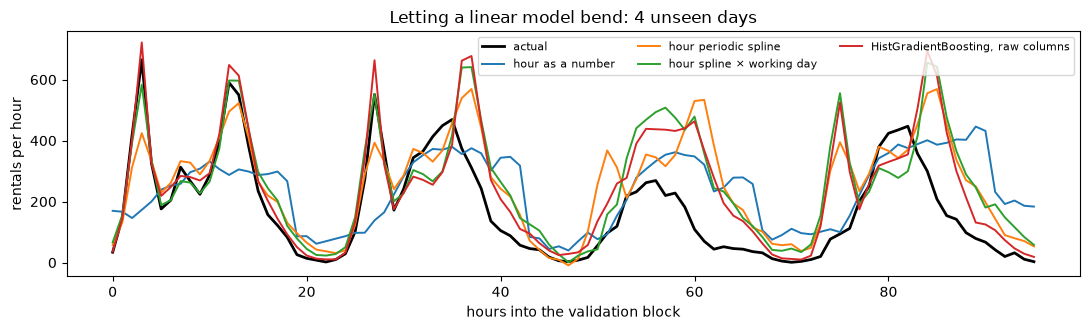

In [12]:
last_train, last_valid = list(bike_cv.split(bike_X))[-1]
window = last_valid[:96]                                               # the first 4 days of the last validation block
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(np.arange(96), bike_y.iloc[window].to_numpy(), color="black", lw=2, label="actual")
for name in ["hour as a number", "hour periodic spline", "hour spline × working day", "HistGradientBoosting, raw columns"]:
    model = clone(bike_models[name]).fit(bike_X.iloc[last_train], bike_y.iloc[last_train])
    ax.plot(np.arange(96), model.predict(bike_X.iloc[window]), lw=1.4, label=name)
ax.set(xlabel="hours into the validation block", ylabel="rentals per hour", title="Letting a linear model bend: 4 unseen days")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

Each step gives the linear model a shape it couldn't draw before, and the interaction lets working days have commuter peaks while weekends don't. Gradient boosting still wins because it discovers such interactions (hour × weather × season …) automatically, but the engineered Ridge model is tiny, fast and fully explainable.

### ✍️ Your Turn

How many output columns does `PolynomialFeatures(degree=2, include_bias=False)` create from **5** input features? Fit it on a 1×5 array and store `len(poly.get_feature_names_out())` in `n_poly_columns`.

In [13]:
n_poly_columns = None  # TODO: your code here
check("n_poly_columns", n_poly_columns, 20, hint="5 originals + 5 squares + C(5, 2) = 10 pairwise products")

⏳ n_poly_columns: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
poly = PolynomialFeatures(degree=2, include_bias=False).fit(np.ones((1, 5)))
n_poly_columns = len(poly.get_feature_names_out())
check("n_poly_columns", n_poly_columns, 20)
```

In general degree 2 on d features gives d + d + d(d−1)/2 columns: 36 Ames numeric columns → 702 columns. That growth is why you add interactions **selectively** (Pitfall 5 shows what happens otherwise).
</details>

> 💡 **Interview angle:** "How would you model a cyclical or non-linear feature in a linear model?" — one-hot or bins for a few levels, periodic splines or sine/cosine for cycles (hour, day of year), interactions for effects that depend on context (hour × working day). Validate with a time-aware split, and remember trees capture this automatically.

## 5. Categorical Encoding: One-Hot, Ordinal and Hashing 🟢

Most models need numbers. **Cardinality** = how many distinct levels a categorical column has (`CentralAir`: 2, `Neighborhood`: 25, an Amazon `RESOURCE` ID: 7,518).

| Encoder | Output | Good for | Watch out |
|---|---|---|---|
| `OneHotEncoder` | one 0/1 column per level | nominal columns with few levels; linear models | width explodes with cardinality; `handle_unknown` for new levels; `min_frequency` / `max_categories` group rare levels |
| `OrdinalEncoder` | one integer per level | **truly ordered** levels (`Po < Fa < TA < Gd < Ex`) given explicitly; tree models | the default alphabetical order is a *fake* order for linear models |
| `FeatureHasher` | hash each `"column=value"` into a fixed number of columns | huge or unbounded vocabularies, streaming | collisions (two levels share a column); not invertible |
| `TargetEncoder` | average target per level (Section 6) | high cardinality | leaks the label unless cross-fitted |
| native support | model splits on categories directly | HistGradientBoosting (≤ 255 levels), LightGBM, CatBoost | each library has its own rules |

`handle_unknown` options for `OneHotEncoder`: `"error"` (crash on a new level), `"ignore"` (all zeros), `"infrequent_if_exist"` (map to the rare-levels column). For an unregularized linear model, `drop="if_binary"` or `drop="first"` avoids perfectly collinear columns; with Ridge/Lasso keeping all levels is fine.

First, **Ames with a linear model**: the same numeric preprocessing every time, only the handling of the 43 text columns changes.

In [14]:
SKEWED_RAW = [c for c in AREA_COLS if c in NUM_RAW]
OTHER_RAW = [c for c in NUM_RAW if c not in SKEWED_RAW]
numeric_part = [
    ("skewed", make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(np.log1p, feature_names_out="one-to-one"), StandardScaler()), SKEWED_RAW),
    ("numeric", make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), OTHER_RAW),
]
fill_none = SimpleImputer(strategy="constant", fill_value="None")
encoding_options = {
    "drop the text columns": [],
    "ordinal codes, alphabetical order (fake order)": [
        ("text", make_pipeline(clone(fill_none), OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), StandardScaler()), CAT_RAW)],
    "one-hot, every level": [("text", make_pipeline(clone(fill_none), OneHotEncoder(handle_unknown="ignore", sparse_output=False)), CAT_RAW)],
    "one-hot, levels < 10 rows grouped": [
        ("text", make_pipeline(clone(fill_none), OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False)), CAT_RAW)],
    "true order for quality + grouped one-hot for the rest": [
        ("quality", make_pipeline(clone(fill_none), OrdinalEncoder(categories=[QUALITY_ORDER] * len(QUALITY_COLS), handle_unknown="use_encoded_value",
                                                                   unknown_value=-1), StandardScaler()), QUALITY_COLS),
        ("nominal", make_pipeline(clone(fill_none), OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False)), NOMINAL)],
}
encoding_rows = {}
for name, text_part in encoding_options.items():
    prep = ColumnTransformer(numeric_part + text_part)
    rmse_mean, rmse_std = cv_rmse(log_target(make_pipeline(prep, RidgeCV(alphas=ALPHAS))), ames_X)
    encoding_rows[name] = {"CV RMSE ($)": rmse_mean, "fold std ($)": rmse_std, "columns": clone(prep).fit_transform(ames_X).shape[1]}
encoding_table = pd.DataFrame(encoding_rows).T
print(encoding_table.round(0))
best_encoding = encoding_table["CV RMSE ($)"].idxmin()
print(f"\nbest: {best_encoding} | dropping the text columns costs "
      f"${encoding_table.loc['drop the text columns', 'CV RMSE ($)'] - encoding_table.loc[best_encoding, 'CV RMSE ($)']:,.0f} of RMSE")

                                                    CV RMSE ($)  fold std ($)  columns
drop the text columns                                   31975.0        7720.0     37.0
ordinal codes, alphabetical order (fake order)          31850.0        7828.0     80.0
one-hot, every level                                    29821.0        8938.0    302.0
one-hot, levels < 10 rows grouped                       29873.0        8731.0    254.0
true order for quality + grouped one-hot for th...      29825.0        8085.0    220.0

best: one-hot, every level | dropping the text columns costs $2,154 of RMSE


In [15]:
neighborhood_encoder = OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False).fit(ames_X[["Neighborhood"]])
print("Neighborhood levels grouped as infrequent:", neighborhood_encoder.infrequent_categories_[0].tolist())
new_house = pd.DataFrame({"Neighborhood": ["Blueste", "BrandNewSubdivision"]})       # one rare level, one never seen
encoded = pd.DataFrame(neighborhood_encoder.transform(new_house), columns=neighborhood_encoder.get_feature_names_out(), index=new_house["Neighborhood"])
print("\nboth rows land in the infrequent column:\n", encoded.loc[:, encoded.any()].to_string())

Neighborhood levels grouped as infrequent: ['Blueste', 'NPkVill', 'Veenker']

both rows land in the infrequent column:
                      Neighborhood_infrequent_sklearn
Neighborhood                                        
Blueste                                          1.0
BrandNewSubdivision                              1.0


**High cardinality: Amazon Employee Access.** Each request is described only by IDs: the resource asked for, the manager, the role, the department… Levels run into the thousands, and the label says whether access was granted (94% yes). We hold out 25% of rows for this section and the next.

One-hot creates one column per ID; hashing squeezes everything into a fixed width; tree libraries can split on categories natively. Metric: ROC-AUC on the held-out rows (1.0 = perfect ranking, 0.5 = random).

In [16]:
amz_X = amazon.data.astype(str)
amz_y = (amazon.target == "1").astype(int).to_numpy()
amz_X_train, amz_X_test, amz_y_train, amz_y_test = train_test_split(amz_X, amz_y, test_size=0.25, stratify=amz_y, random_state=SEED)
print("levels per column (training rows):", amz_X_train.nunique().to_dict())
singletons = (amz_X_train["RESOURCE"].value_counts() == 1).mean()
print(f"{singletons:.0%} of RESOURCE levels appear in exactly one training row")


def as_tokens(frame):
    """Turn each row into strings like 'RESOURCE=4675' for the hashing trick."""
    return [[f"{col}={value}" for col, value in zip(frame.columns, row)] for row in frame.itertuples(index=False)]


amazon_results = {}


def evaluate_amazon(name, model, X_train=amz_X_train, X_test=amz_X_test, n_columns=None):
    start = time.perf_counter()
    model.fit(X_train, amz_y_train)
    fit_s = time.perf_counter() - start
    amazon_results[name] = {"test ROC-AUC": roc_auc_score(amz_y_test, model.predict_proba(X_test)[:, 1]), "columns": n_columns, "fit s": fit_s}


evaluate_amazon("one-hot, every level + logistic regression",
                make_pipeline(OneHotEncoder(handle_unknown="ignore"), LogisticRegression(max_iter=2000)),
                n_columns=OneHotEncoder(handle_unknown="ignore").fit(amz_X_train).transform(amz_X_train).shape[1])
evaluate_amazon("one-hot, levels < 5 rows grouped + logistic regression",
                make_pipeline(OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5), LogisticRegression(max_iter=2000)),
                n_columns=OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=5).fit(amz_X_train).transform(amz_X_train).shape[1])
evaluate_amazon("hashing 2^18 + logistic regression",
                make_pipeline(FunctionTransformer(as_tokens), FeatureHasher(n_features=2**18, input_type="string"), LogisticRegression(max_iter=2000)),
                n_columns=2**18)
evaluate_amazon("ordinal codes (arbitrary) + HistGradientBoosting",
                make_pipeline(OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), HistGradientBoostingClassifier(random_state=SEED)),
                n_columns=amz_X.shape[1])
print(pd.DataFrame(amazon_results).T.round(4))

levels per column (training rows): {'RESOURCE': 6481, 'MGR_ID': 3965, 'ROLE_ROLLUP_1': 123, 'ROLE_ROLLUP_2': 171, 'ROLE_DEPTNAME': 440, 'ROLE_TITLE': 330, 'ROLE_FAMILY_DESC': 2158, 'ROLE_FAMILY': 66, 'ROLE_CODE': 330}
54% of RESOURCE levels appear in exactly one training row


                                                    test ROC-AUC   columns   fit s
one-hot, every level + logistic regression                0.8570   14064.0  0.1095
one-hot, levels < 5 rows grouped + logistic reg...        0.8467    4392.0  0.1479
hashing 2^18 + logistic regression                        0.8575  262144.0  0.7862
ordinal codes (arbitrary) + HistGradientBoosting          0.8165       9.0  1.1161


**Native categorical support** in tree libraries (details in [Gradient Boosting](10_Gradient_Boosting.ipynb)):

- scikit-learn's `HistGradientBoosting*` accepts `categorical_features="from_dtype"`, but only up to **255 levels** per column.
- **LightGBM** splits categories by sorting levels by their gradient statistics; pass pandas `category` columns.
- **CatBoost** uses *ordered target statistics*: a built-in, leak-resistant target encoding computed along a random permutation of rows.

To give pandas the same category list at training and test time, unseen test IDs become missing values.

In [17]:
amz_categories = {col: pd.Index(sorted(amz_X_train[col].unique())) for col in amz_X.columns}


def to_category(frame):
    return pd.DataFrame({col: pd.Categorical(frame[col].where(frame[col].isin(amz_categories[col])), categories=amz_categories[col])
                         for col in frame.columns}, index=frame.index)


amz_cat_train, amz_cat_test = to_category(amz_X_train), to_category(amz_X_test)
try:
    HistGradientBoostingClassifier(categorical_features="from_dtype").fit(amz_cat_train, amz_y_train)
except ValueError as err:
    print("HistGradientBoosting native categories →", err)

evaluate_amazon("LightGBM native categories", lightgbm.LGBMClassifier(n_estimators=300, learning_rate=0.05, n_jobs=4, verbose=-1, random_state=SEED),
                X_train=amz_cat_train, X_test=amz_cat_test, n_columns=amz_X.shape[1])
catboost_model = catboost.CatBoostClassifier(iterations=300, random_seed=SEED, thread_count=4, verbose=0, allow_writing_files=False,
                                             cat_features=list(range(amz_X.shape[1])))
evaluate_amazon("CatBoost native categories (ordered target statistics)", catboost_model, n_columns=amz_X.shape[1])
amazon_table = pd.DataFrame(amazon_results).T.sort_values("test ROC-AUC", ascending=False)
print(amazon_table.round(4))
print(f"\nbest so far: {amazon_table.index[0]} (AUC {amazon_table['test ROC-AUC'].iloc[0]:.3f}); "
      f"arbitrary ordinal codes: {amazon_results['ordinal codes (arbitrary) + HistGradientBoosting']['test ROC-AUC']:.3f}")

HistGradientBoosting native categories → Categorical feature 'RESOURCE' is expected to have a cardinality <= 255 but actually has a cardinality of 6481.


                                                    test ROC-AUC   columns   fit s
CatBoost native categories (ordered target stat...        0.8863       9.0  2.8631
LightGBM native categories                                0.8592       9.0  0.7695
hashing 2^18 + logistic regression                        0.8575  262144.0  0.7862
one-hot, every level + logistic regression                0.8570   14064.0  0.1095
one-hot, levels < 5 rows grouped + logistic reg...        0.8467    4392.0  0.1479
ordinal codes (arbitrary) + HistGradientBoosting          0.8165       9.0  1.1161

best so far: CatBoost native categories (ordered target statistics) (AUC 0.886); arbitrary ordinal codes: 0.816


Arbitrary integer IDs give trees little to work with (similar numbers aren't similar resources), while one-hot, hashing and CatBoost's target statistics all do much better. Hashing matches one-hot at a fixed width, which is why it is used for ad click models with billions of IDs.

### ✍️ Your Turn

Fit `OneHotEncoder(min_frequency=3, handle_unknown="infrequent_if_exist")` on the `paint` table and store `list(encoder.get_feature_names_out())` in `paint_columns`.

In [18]:
paint = pd.DataFrame({"color": ["red"] * 5 + ["blue"] * 3 + ["green", "pink"]})
paint_columns = None  # TODO: your code here
check("paint_columns", paint_columns, ["color_blue", "color_red", "color_infrequent_sklearn"],
      hint="Levels seen fewer than 3 times (green, pink) are grouped into one column placed last.")

⏳ paint_columns: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
paint = pd.DataFrame({"color": ["red"] * 5 + ["blue"] * 3 + ["green", "pink"]})
encoder = OneHotEncoder(min_frequency=3, handle_unknown="infrequent_if_exist").fit(paint)
paint_columns = list(encoder.get_feature_names_out())
check("paint_columns", paint_columns, ["color_blue", "color_red", "color_infrequent_sklearn"])
```

`encoder.infrequent_categories_` shows `['green', 'pink']`. At prediction time, a brand-new colour also goes to `color_infrequent_sklearn` instead of crashing.
</details>

> 💡 **Interview angle:** "How do you encode a categorical feature with 10,000 levels?" — not plain one-hot into a dense model. Options: group rare levels (`min_frequency`), hashing (fixed width, collisions), cross-fitted target encoding, learned embeddings (neural nets), or a library with native categorical handling (CatBoost, LightGBM). Choose with CV, and plan for unseen levels in production.

## 6. Target Encoding and Its Leak 🔴

**Target encoding** replaces each level with the average target of that level, **shrunk** toward the global average when the level has few rows:

$$\text{enc}(c) = \lambda_c\, \bar y_c + (1 - \lambda_c)\, \bar y, \qquad \lambda_c = \frac{n_c}{n_c + m} \;\;(\texttt{smooth}=m)$$

With `smooth="auto"`, scikit-learn uses an empirical-Bayes weight $\lambda_c = \frac{n_c\, \sigma^2}{n_c\, \sigma^2 + \sigma_c^2}$ ($\sigma^2$ = target variance, $\sigma_c^2$ = variance inside the level): noisy, rare levels lean on the global mean.

**The leak.** Encode the training rows using statistics that *include their own label*, and a level seen once gets encoding = its own label. The model learns "encoding ≈ answer", which is useless on new rows. **Cross fitting** fixes it: `TargetEncoder.fit_transform` splits the training data into k folds and encodes each fold with statistics from the *other* folds; `transform` on new data uses all training rows. So `fit(X).transform(X)` ≠ `fit_transform(X)` — on purpose.

In scikit-learn 1.9 the `shuffle` and `random_state` arguments are deprecated: pass a splitter such as `cv=StratifiedKFold(5, shuffle=True, random_state=SEED)` for reproducible folds.

**Experiment on Amazon:** the naive way (`fit` then `transform` on the same training rows) vs cross-fitted (`fit_transform`), each feeding logistic regression and HistGradientBoosting. Test rows are always encoded with `transform`.

In [19]:
amz_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
target_encoder = TargetEncoder(cv=amz_folds)
cross_fitted_train = target_encoder.fit_transform(amz_X_train, amz_y_train)     # each row encoded without its own fold
naive_train = target_encoder.transform(amz_X_train)                             # ❌ each row's own label is inside its encoding
encoded_test = target_encoder.transform(amz_X_test)

leak_rows = []
for encoding_name, train_features in [("naive fit→transform", naive_train), ("cross-fitted fit_transform", cross_fitted_train)]:
    for model_name, model in [("logistic regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))),
                              ("HistGradientBoosting", HistGradientBoostingClassifier(random_state=SEED))]:
        model.fit(train_features, amz_y_train)
        leak_rows.append({"encoding": encoding_name, "model": model_name,
                          "train AUC": roc_auc_score(amz_y_train, model.predict_proba(train_features)[:, 1]),
                          "test AUC": roc_auc_score(amz_y_test, model.predict_proba(encoded_test)[:, 1])})
        amazon_results[f"target encoding ({encoding_name}) + {model_name}"] = {"test ROC-AUC": leak_rows[-1]["test AUC"], "columns": amz_X.shape[1]}
leak_table = pd.DataFrame(leak_rows)
leak_table["train − test gap"] = leak_table["train AUC"] - leak_table["test AUC"]
print(leak_table.round(4).to_string(index=False))

                  encoding                model  train AUC  test AUC  train − test gap
       naive fit→transform  logistic regression     0.9820    0.8165            0.1654
       naive fit→transform HistGradientBoosting     0.9969    0.7635            0.2334
cross-fitted fit_transform  logistic regression     0.8359    0.8367           -0.0008
cross-fitted fit_transform HistGradientBoosting     0.9407    0.8525            0.0882


❌ encode all training rows first, then cross-validate: CV AUC 0.982
✅ TargetEncoder inside the pipeline:                   CV AUC 0.834  (test AUC 0.837)


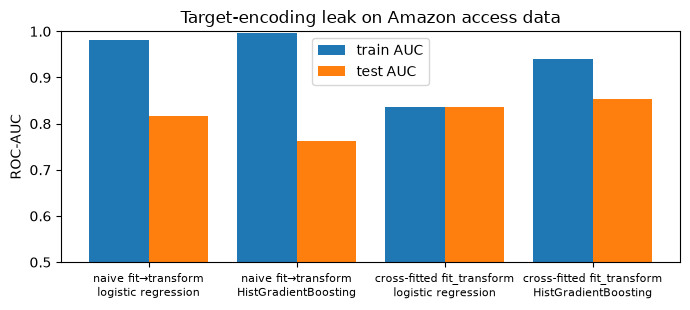

                                                    test ROC-AUC
CatBoost native categories (ordered target stat...        0.8863
LightGBM native categories                                0.8592
hashing 2^18 + logistic regression                        0.8575
one-hot, every level + logistic regression                0.8570
target encoding (cross-fitted fit_transform) + ...        0.8525
one-hot, levels < 5 rows grouped + logistic reg...        0.8467
target encoding (cross-fitted fit_transform) + ...        0.8367
target encoding (naive fit→transform) + logisti...        0.8165
ordinal codes (arbitrary) + HistGradientBoosting          0.8165
target encoding (naive fit→transform) + HistGra...        0.7635


In [20]:
# The same leak, disguised as a great cross-validation score
leaky_cv = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), naive_train, amz_y_train,
                           cv=amz_folds, scoring="roc_auc").mean()
honest_cv = cross_val_score(make_pipeline(TargetEncoder(cv=amz_folds), StandardScaler(), LogisticRegression(max_iter=2000)),
                            amz_X_train, amz_y_train, cv=amz_folds, scoring="roc_auc").mean()
lr_test = leak_table.query("model == 'logistic regression'").set_index("encoding")["test AUC"]
print(f"❌ encode all training rows first, then cross-validate: CV AUC {leaky_cv:.3f}")
print(f"✅ TargetEncoder inside the pipeline:                   CV AUC {honest_cv:.3f}  (test AUC {lr_test['cross-fitted fit_transform']:.3f})")

fig, ax = plt.subplots(figsize=(7, 3.2))
labels = [f"{r.encoding}\n{r.model}" for r in leak_table.itertuples()]
positions = np.arange(len(leak_table))
ax.bar(positions - 0.2, leak_table["train AUC"], width=0.4, label="train AUC")
ax.bar(positions + 0.2, leak_table["test AUC"], width=0.4, label="test AUC")
ax.set_xticks(positions, labels, fontsize=8)
ax.set(ylim=(0.5, 1.0), ylabel="ROC-AUC", title="Target-encoding leak on Amazon access data")
ax.legend()
plt.tight_layout()
plt.show()
print(pd.DataFrame(amazon_results).T.sort_values("test ROC-AUC", ascending=False)[["test ROC-AUC"]].round(4))

The naive encoding lets gradient boosting memorize the training labels (near-perfect train AUC) and it pays for it on test. Cross fitting closes most of that gap. CatBoost's ordered target statistics apply the same idea internally, which is one reason it shines on data like this.

### ✍️ Your Turn

Level `"a"` has 3 rows, all with label 1; level `"b"` has 12 rows with label 0, so the global mean is 0.2. Compute the smoothed encoding of `"a"` with `smooth = 2` **by hand** and store it in `enc_a`.

In [21]:
enc_a = None  # TODO: (sum of labels in "a" + smooth * global mean) / (rows in "a" + smooth)
check("enc_a", enc_a, 0.68, hint="(3 + 2 * 0.2) / (3 + 2)")

⏳ enc_a: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
enc_a = (3 + 2 * 0.2) / (3 + 2)
check("enc_a", enc_a, 0.68)
toy_X = pd.DataFrame({"level": ["a"] * 3 + ["b"] * 12})
toy_y = np.array([1] * 3 + [0] * 12)
print(TargetEncoder(smooth=2.0).fit(toy_X, toy_y).encodings_[0])   # [0.68, 0.0286]: the same numbers from scikit-learn
```

The raw mean of "a" is 1.0, but with only 3 rows it is pulled toward the global 0.2. The Build It From Scratch section reproduces `fit_transform` exactly, cross fitting included.
</details>

> 💡 **Interview angle:** "What's the risk with target encoding and how do you avoid it?" — target leakage: a row's own label contributes to its encoding, so models overfit (worst for rare levels). Use out-of-fold (cross-fitted) encodings for training rows, smoothing toward the global mean, fit the encoder inside the CV pipeline, and encode test data with training statistics only.

## 7. Missing Values: Imputers and Informative Missingness 🟡

Why is a value missing? Statisticians use three labels:

- **MCAR** (missing completely at random): a sensor randomly dropped a reading. Filling is safe.
- **MAR** (missing at random given other columns): age is missing more often for 3rd-class passengers. Other features can predict it.
- **MNAR** (missing not at random): the value is missing *because of* its own value or the outcome — e.g. a cabin number wasn't recorded for passengers who didn't survive to report it. **Missingness itself carries signal.**

And sometimes NaN isn't unknown at all: in Ames, `PoolQC` is NaN because there is **no pool** (structural missingness → fill with a "None" level).

| Tool | How it fills | Notes |
|---|---|---|
| `SimpleImputer(strategy=...)` | mean / median / most frequent / constant | `add_indicator=True` appends a 0/1 "was missing" column |
| `KNNImputer(n_neighbors=5)` | average of the nearest rows | needs scaled features; O(n²) |
| `IterativeImputer` | regress each column on the others, repeat | experimental: `from sklearn.experimental import enable_iterative_imputer` |
| HistGradientBoosting / LightGBM / XGBoost | learn which branch NaN goes to | no imputation needed |

**Titanic** (we dropped the `boat`, `body` and `home.dest` columns: they were recorded *after* the sinking and leak the outcome — Pitfall 1):

In [22]:
titanic_y = titanic["survived"].astype(int)
missing_share = titanic[["age", "fare", "cabin", "embarked"]].isna().mean()
print("share missing:", missing_share.round(3).to_dict())
for col in ["cabin", "age"]:
    rates = titanic_y.groupby(titanic[col].isna().map({False: "known", True: "missing"})).mean()
    print(f"survival when {col} is known {rates['known']:.1%} vs missing {rates['missing']:.1%}")

pool_nan = ames["PoolQC"].isna()
print(f"\nAmes: PoolQC missing for {pool_nan.sum():,} houses; PoolArea == 0 for {(ames['PoolArea'] == 0).sum():,}; "
      f"they agree on {(pool_nan == (ames['PoolArea'] == 0)).mean():.1%} of rows → NaN means 'no pool'")

share missing: {'age': 0.201, 'fare': 0.001, 'cabin': 0.775, 'embarked': 0.002}
survival when cabin is known 65.4% vs missing 30.3%
survival when age is known 40.8% vs missing 27.8%

Ames: PoolQC missing for 1,453 houses; PoolArea == 0 for 1,453; they agree on 100.0% of rows → NaN means 'no pool'


In [23]:
TITANIC_NUM = ["pclass", "age", "sibsp", "parch", "fare"]
TITANIC_CAT = ["sex", "embarked"]
titanic_X = titanic[TITANIC_NUM + TITANIC_CAT].assign(cabin_missing=titanic["cabin"].isna().astype(int))
titanic_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=SEED)
categorical_steps = ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), TITANIC_CAT)


def titanic_lr(numeric_imputation, numeric_cols=TITANIC_NUM):
    return make_pipeline(ColumnTransformer([("num", numeric_imputation, numeric_cols), categorical_steps]), LogisticRegression(max_iter=2000))


imputation_models = {
    "median": titanic_lr(make_pipeline(SimpleImputer(strategy="median"), StandardScaler())),
    "median + missing indicators": titanic_lr(make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler())),
    "KNNImputer (k=5, on scaled data)": titanic_lr(make_pipeline(StandardScaler(), KNNImputer(n_neighbors=5))),
    "IterativeImputer": titanic_lr(make_pipeline(StandardScaler(), IterativeImputer(max_iter=10, random_state=SEED))),
    "median + indicators + cabin_missing": titanic_lr(make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()),
                                                      TITANIC_NUM + ["cabin_missing"]),
    "HistGradientBoosting, NaN left as is + cabin_missing": HistGradientBoostingClassifier(categorical_features="from_dtype", max_iter=150,
                                                                                          learning_rate=0.05, random_state=SEED),
}
imputation_rows = {}
for name, model in imputation_models.items():
    columns = titanic_X.columns if ("cabin_missing" in name) else TITANIC_NUM + TITANIC_CAT
    scores = cross_val_score(model, titanic_X[columns], titanic_y, cv=titanic_cv, scoring="roc_auc")
    imputation_rows[name] = {"CV ROC-AUC": scores.mean(), "std over 20 folds": scores.std()}
imputation_table = pd.DataFrame(imputation_rows).T
print(imputation_table.round(4))
lr_only = imputation_table.iloc[:4]["CV ROC-AUC"]
cabin_gain = imputation_table.loc["median + indicators + cabin_missing", "CV ROC-AUC"] - imputation_table.loc["median + missing indicators", "CV ROC-AUC"]
print(f"\nThe four ways to fill age/fare differ by only {lr_only.max() - lr_only.min():.4f} AUC (fold std ≈ {imputation_table['std over 20 folds'].mean():.3f}); "
      f"adding the cabin_missing flag changes AUC by {cabin_gain:+.4f}.")

                                                    CV ROC-AUC  std over 20 folds
median                                                  0.8390             0.0207
median + missing indicators                             0.8394             0.0215
KNNImputer (k=5, on scaled data)                        0.8394             0.0206
IterativeImputer                                        0.8391             0.0202
median + indicators + cabin_missing                     0.8421             0.0211
HistGradientBoosting, NaN left as is + cabin_mi...      0.8530             0.0260

The four ways to fill age/fare differ by only 0.0005 AUC (fold std ≈ 0.022); adding the cabin_missing flag changes AUC by +0.0028.


An honest result: **how** you fill age barely matters here, because `pclass`, `sex` and `fare` already carry most of the information that age and cabin-missingness hold (3rd-class passengers rarely had a recorded cabin). Missingness is strongly related to survival (the rates above), yet most of that signal was already in the model. Always measure: in data where the missing flag isn't redundant (credit applications, medical tests that were never ordered) indicators often help a lot.

### ✍️ Your Turn

What does `SimpleImputer(strategy="mean", add_indicator=True)` return for `[[1], [nan], [3]]`? Store the output array in `imputed_with_flag`.

In [24]:
column_with_gap = np.array([[1.0], [np.nan], [3.0]])
imputed_with_flag = None  # TODO: your code here
check("imputed_with_flag", imputed_with_flag, [[1, 0], [2, 1], [3, 0]], hint="SimpleImputer(strategy='mean', add_indicator=True).fit_transform(column_with_gap)")

⏳ imputed_with_flag: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
column_with_gap = np.array([[1.0], [np.nan], [3.0]])
imputed_with_flag = SimpleImputer(strategy="mean", add_indicator=True).fit_transform(column_with_gap)
check("imputed_with_flag", imputed_with_flag, [[1, 0], [2, 1], [3, 0]])
```

The mean of the observed values (2) fills the gap, and the extra column remembers *which* row was filled. Indicators are only added for columns that had missing values during `fit`.
</details>

> 💡 **Interview angle:** "How do you handle missing values?" — first ask *why* they're missing (structural, MCAR/MAR/MNAR). Structural → explicit level or 0; otherwise impute inside the pipeline (median, KNN, iterative) and add missing indicators when missingness may be informative; or use models with native NaN handling. Never drop rows blindly, and never fit the imputer on test data.

## 8. Dates, Text-Lite Features and Group Aggregates 🟡

**Cyclical time.** Hour 23 and hour 0 are one hour apart, but as numbers they are 23 apart. Mapping the hour onto a circle fixes that:

$$\text{hour} \mapsto \big(\sin(2\pi \cdot \text{hour}/24),\; \cos(2\pi \cdot \text{hour}/24)\big)$$

You need **both** coordinates: sine alone gives 6:00 and 18:00 different values but 0:00 and 12:00 the same. The same trick works for day of week (period 7) and month (12). Section 4 showed that on bike data a periodic spline beat sine/cosine for Ridge: two coordinates can only draw one smooth wave per day, splines can draw two peaks.

distance 23:00 ↔ 00:00 — as numbers 23, on the circle 0.261; 06:00 ↔ 18:00 on the circle 2.000 (opposite sides)


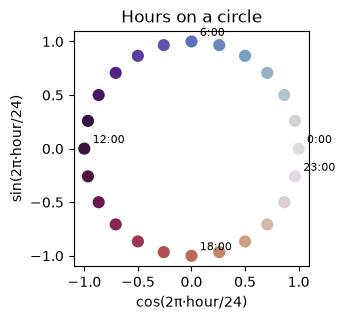

In [25]:
hours = np.arange(24)
circle = sin_cos(hours.reshape(-1, 1), period=24)
print(f"distance 23:00 ↔ 00:00 — as numbers {abs(23 - 0)}, on the circle {np.linalg.norm(circle[23] - circle[0]):.3f}; "
      f"06:00 ↔ 18:00 on the circle {np.linalg.norm(circle[6] - circle[18]):.3f} (opposite sides)")
fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.scatter(circle[:, 1], circle[:, 0], c=hours, cmap="twilight", s=60)
for h in [0, 6, 12, 18, 23]:
    ax.annotate(f"{h}:00", (circle[h, 1], circle[h, 0]), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set(xlabel="cos(2π·hour/24)", ylabel="sin(2π·hour/24)", title="Hours on a circle", aspect="equal")
plt.tight_layout()
plt.show()

**Time since an event** (house age, days since last purchase, account tenure) is usually more meaningful than the raw date. A subtle point: a *linear* model given `YearBuilt` and `YrSold` can already form `YrSold − YearBuilt` as a weighted sum, so the explicit difference adds little. A *tree* can't add columns together, so explicit differences and totals can help it. Let's test both on the Ames numeric columns.

In [26]:
engineered_names = ["TotalSF", "HouseAge", "YearsSinceRemodel", "TotalBath", "TotalPorchSF"]
ames_num_eng = add_ames_features(ames_X)[NUM_RAW + engineered_names]
time_rows = {}
for label, frame in [("36 raw numeric columns", ames_num), ("+ totals, ages and bath count", ames_num_eng)]:
    time_rows[label] = {
        "Ridge, log target": cv_rmse(log_target(make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), RidgeCV(alphas=ALPHAS))), frame)[0],
        "HistGradientBoosting": cv_rmse(HistGradientBoostingRegressor(random_state=SEED), frame)[0],
    }
time_table = pd.DataFrame(time_rows).T
print(time_table.round(0))
gains = time_table.iloc[0] - time_table.iloc[1]
print(f"\nRMSE improvement from the new columns: Ridge ${gains['Ridge, log target']:,.0f}, HistGradientBoosting ${gains['HistGradientBoosting']:,.0f}")

                               Ridge, log target  HistGradientBoosting
36 raw numeric columns                   47211.0               30079.0
+ totals, ages and bath count            47842.0               29178.0

RMSE improvement from the new columns: Ridge $-631, HistGradientBoosting $900


**Text-lite features** pull structure out of short strings without any NLP model. On Titanic:

- **title** from the name ("Braund, **Mr**. Owen Harris"): encodes sex, age group and status at once (`Master` = young boy);
- **family size** = siblings/spouses + parents/children + 1;
- **deck** = first letter of the cabin;
- **ticket group size** = how many passengers share the ticket.

The first three are **row-wise** (safe anywhere). The ticket count looks at *other rows*, so it must be **learned in `fit`** from training rows only; computing it on the whole dataset lets validation/test passengers influence training features. A tiny custom transformer does it properly.

In [27]:
def add_titanic_text_features(df):
    title = df["name"].str.extract(r",\s*([^\.]+)\.", expand=False).replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    return df.assign(
        title=title.where(title.isin(["Mr", "Mrs", "Miss", "Master"]), "Rare"),
        family_size=df["sibsp"] + df["parch"] + 1,
        deck=df["cabin"].str[0].fillna("Unknown"),
        cabin_missing=df["cabin"].isna().astype(int),
    )


class FrequencyEncoder(TransformerMixin, BaseEstimator):
    """Replace each level by how many training rows share it (unseen levels → 0). Learned in fit, so no leakage."""

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.counts_ = {col: X[col].value_counts() for col in X.columns}
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        check_is_fitted(self, "counts_")
        X = pd.DataFrame(X)
        return pd.DataFrame({f"{col}_count": X[col].map(self.counts_[col]).fillna(0).astype(float) for col in X.columns}, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.asarray([f"{col}_count" for col in self.feature_names_in_], dtype=object)


print(add_titanic_text_features(titanic.head(4))[["name", "title", "family_size", "deck"]].to_string(index=False))


def titanic_text_model(numeric, categorical, with_ticket_counts):
    parts = [("num", make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), numeric),
             ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), categorical)]
    if with_ticket_counts:
        parts.append(("ticket", make_pipeline(FrequencyEncoder(), StandardScaler()), ["ticket"]))
    return make_pipeline(FunctionTransformer(add_titanic_text_features), ColumnTransformer(parts), LogisticRegression(max_iter=2000))


text_models = {
    "base columns": titanic_text_model(TITANIC_NUM, TITANIC_CAT, False),
    "+ title, family size, deck, cabin_missing": titanic_text_model(TITANIC_NUM + ["family_size", "cabin_missing"],
                                                                    TITANIC_CAT + ["title", "deck"], False),
    "+ ticket group size (learned in fit)": titanic_text_model(TITANIC_NUM + ["family_size", "cabin_missing"],
                                                               TITANIC_CAT + ["title", "deck"], True),
}
titanic_raw = titanic.drop(columns=["survived", "boat", "body", "home.dest"])
text_scores = pd.DataFrame({name: pd.Series(cross_val_score(model, titanic_raw, titanic_y, cv=titanic_cv, scoring="roc_auc")).agg(["mean", "std"])
                            for name, model in text_models.items()}).T.rename(columns={"mean": "CV ROC-AUC", "std": "std"})
print("\n", text_scores.round(4))
print(f"\ntext-lite features add {text_scores['CV ROC-AUC'].iloc[1] - text_scores['CV ROC-AUC'].iloc[0]:+.4f} AUC; "
      f"ticket counts add {text_scores['CV ROC-AUC'].iloc[2] - text_scores['CV ROC-AUC'].iloc[1]:+.4f} more")

                                name  title  family_size deck
       Allen, Miss. Elisabeth Walton   Miss            1    B
      Allison, Master. Hudson Trevor Master            4    C
        Allison, Miss. Helen Loraine   Miss            4    C
Allison, Mr. Hudson Joshua Creighton     Mr            4    C



                                            CV ROC-AUC     std
base columns                                   0.8394  0.0221
+ title, family size, deck, cabin_missing      0.8537  0.0180
+ ticket group size (learned in fit)           0.8530  0.0182

text-lite features add +0.0143 AUC; ticket counts add -0.0007 more


**Group aggregates** compare a row with its group: "this house is 30% bigger than the typical house in its neighbourhood". The group statistic (a median here) is learned in `fit` from training rows, exactly like the frequency encoder. If the statistic uses the **target** (average price per neighbourhood), it *is* target encoding and needs cross fitting (Section 6).

In [28]:
class GroupRatio(TransformerMixin, BaseEstimator):
    """value / median(value within group), with medians learned on training rows; unseen groups use the global median."""

    def __init__(self, group_col="Neighborhood", value_col="GrLivArea"):
        self.group_col = group_col
        self.value_col = value_col

    def fit(self, X, y=None):
        self.group_medians_ = X.groupby(self.group_col, observed=True)[self.value_col].median()
        self.global_median_ = float(X[self.value_col].median())
        return self

    def transform(self, X):
        check_is_fitted(self, "group_medians_")
        reference = X[self.group_col].map(self.group_medians_).astype(float).fillna(self.global_median_)
        return pd.DataFrame({self.get_feature_names_out()[0]: X[self.value_col] / reference}, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.asarray([f"{self.value_col}_vs_{self.group_col}_median"], dtype=object)


print(GroupRatio().fit(ames_X).transform(ames_X.head(3)).assign(Neighborhood=ames_X["Neighborhood"].head(3)).round(3).to_string())
with_ratio = log_target(make_pipeline(
    FunctionTransformer(add_ames_features),
    ColumnTransformer([("engineered", ames_engineered_preprocessor(), NUM_ENG + CAT_RAW),
                       ("ratio", make_pipeline(GroupRatio(), FunctionTransformer(np.log), StandardScaler()), ["Neighborhood", "GrLivArea"])]),
    RidgeCV(alphas=ALPHAS)))
ratio_rmse = cv_rmse(with_ratio, ames_X)[0]
print(f"\nengineered Ridge (Section 1): ${eng_rmse:,.0f} | + size relative to neighbourhood: ${ratio_rmse:,.0f} ({eng_rmse - ratio_rmse:+,.0f})")

      GrLivArea_vs_Neighborhood_median Neighborhood
254                              1.064        NAmes
1066                             0.986      Gilbert
638                              0.672      Edwards



engineered Ridge (Section 1): $29,994 | + size relative to neighbourhood: $29,624 (+371)


### ✍️ Your Turn

Encode hours `[6, 18]` as `(sin, cos)` pairs with period 24 and store the 2×2 array in `hour_circle`.

In [29]:
hour_circle = None  # TODO: your code here
check("hour_circle", hour_circle, [[1.0, 0.0], [-1.0, 0.0]], hint="np.column_stack([np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)]) with h = np.array([6, 18])")

⏳ hour_circle: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
h = np.array([6, 18])
hour_circle = np.column_stack([np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24)])
check("hour_circle", hour_circle, [[1.0, 0.0], [-1.0, 0.0]])
```

6:00 sits at the top of the circle and 18:00 at the bottom; the cosine is (numerically almost) 0 for both, so sine is what separates them.
</details>

> 💡 **Interview angle:** "How would you featurize timestamps / IDs / free-text fields for a tabular model?" — cyclical encodings for hour/day/month, time-since-event features, calendar flags (holiday, weekend), simple string parsing (titles, prefixes, lengths), and counts/group statistics **learned on the training window only** — for time series, computed from the past relative to each row.

## 9. Filter Selection: Variance, Correlation, Mutual Information, Chi-Squared 🟡

**Filter methods** score each feature on its own, without training the final model. They're fast and a good first pass, but they ignore interactions ("useless alone, great together") and redundancy (two copies of the same signal both score high).

| Score | Measures | Use for |
|---|---|---|
| `VarianceThreshold` | how much a column varies (label not used) | dropping constant / near-constant columns |
| Pearson correlation, `f_regression` / `f_classif` (ANOVA F) | **linear** relationship with the target | quick numeric screens |
| **Mutual information** (`mutual_info_regression` / `_classif`) | *any* dependence: how much knowing $x$ reduces uncertainty about $y$ | non-linear relationships; 0 means independent |
| **χ² (`chi2`)** | dependence between **non-negative** features (counts, one-hot) and a class label | text counts, one-hot categoricals |

Mutual information for discrete variables is

$$I(X;Y) = \sum_{x,y} p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)} = H(Y) - H(Y \mid X)$$

(in nats with the natural log). For continuous features scikit-learn estimates it from k-nearest-neighbour distances (Kraskov et al.), so it's slightly random: fix `random_state`.

**Correlation misses curves.** On bike sharing, rentals depend strongly on the hour, but in a double-peaked way:

           |Pearson r|  mutual information  rank by |r|  rank by MI
hour             0.394               0.630            3           1
temp             0.405               0.146            1           2
feel_temp        0.401               0.145            2           3
humidity         0.323               0.101            4           4
month            0.121               0.072            6           5
year             0.250               0.046            5           6
weekday          0.027               0.017            8           7
windspeed        0.093               0.011            7           8


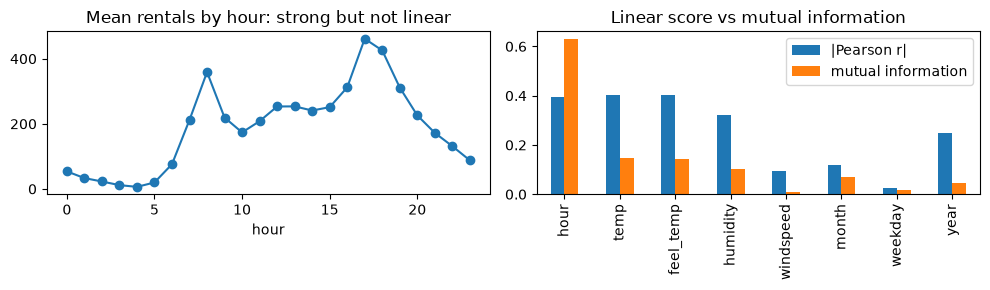

In [30]:
bike_features = ["hour", "temp", "feel_temp", "humidity", "windspeed", "month", "weekday", "year"]
discrete_mask = [c in {"hour", "month", "weekday", "year"} for c in bike_features]
filter_scores = pd.DataFrame({
    "|Pearson r|": bike[bike_features].corrwith(bike["count"]).abs(),
    "mutual information": mutual_info_regression(bike[bike_features], bike["count"], discrete_features=discrete_mask, random_state=SEED),
}, index=bike_features)
filter_scores["rank by |r|"] = filter_scores["|Pearson r|"].rank(ascending=False).astype(int)
filter_scores["rank by MI"] = filter_scores["mutual information"].rank(ascending=False).astype(int)
print(filter_scores.sort_values("mutual information", ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
bike.groupby("hour")["count"].mean().plot(ax=axes[0], marker="o", title="Mean rentals by hour: strong but not linear")
filter_scores[["|Pearson r|", "mutual information"]].plot.bar(ax=axes[1], title="Linear score vs mutual information")
plt.tight_layout()
plt.show()

**Variance and χ² on one-hot columns.** A one-hot column that is 1 for a fraction $p$ of rows has variance $p(1-p)$, so `VarianceThreshold(0.01)` drops dummy columns present in fewer than about 1% of rows. Then χ² and discrete mutual information rank Adult's one-hot categories by how strongly they relate to income.

In [31]:
adult_cat_cols = adult.data.select_dtypes("category").columns.tolist()
adult_onehot = OneHotEncoder(sparse_output=False).set_output(transform="pandas").fit_transform(
    adult.data[adult_cat_cols].apply(lambda s: s.cat.add_categories("missing").fillna("missing")))
adult_y = (adult.target == ">50K").astype(int).to_numpy()
variance_filter = VarianceThreshold(threshold=0.01).fit(adult_onehot)
print(f"Adult one-hot: {adult_onehot.shape[1]} columns → {variance_filter.get_support().sum()} after VarianceThreshold(0.01); "
      f"e.g. dropped: {adult_onehot.columns[~variance_filter.get_support()][:4].tolist()}")

chi2_scores, chi2_p = chi2(adult_onehot, adult_y)
mi_scores = mutual_info_classif(adult_onehot, adult_y, discrete_features=True, random_state=SEED)
ranking = pd.DataFrame({"chi2": chi2_scores, "p-value": chi2_p, "mutual information": mi_scores}, index=adult_onehot.columns)
top_chi2 = set(ranking["chi2"].nlargest(10).index)
top_mi = set(ranking["mutual information"].nlargest(10).index)
print(ranking.sort_values("chi2", ascending=False).head(10).round(4))
print(f"\ntop-10 overlap between chi² and mutual information: {len(top_chi2 & top_mi)} of 10")

Adult one-hot: 102 columns → 54 after VarianceThreshold(0.01); e.g. dropped: ['workclass_Never-worked', 'workclass_Without-pay', 'education_1st-4th', 'education_Preschool']


                                        chi2  p-value  mutual information
marital-status_Married-civ-spouse  5260.4334      0.0              0.1059
relationship_Husband               4748.9174      0.0              0.0820
marital-status_Never-married       3325.5735      0.0              0.0621
relationship_Own-child             2101.6813      0.0              0.0370
occupation_Exec-managerial         1902.4227      0.0              0.0196
occupation_Prof-specialty          1520.8748      0.0              0.0158
sex_Female                         1504.0286      0.0              0.0254
education_Masters                  1401.2501      0.0              0.0128
education_Bachelors                1327.9340      0.0              0.0148
relationship_Not-in-family         1314.0821      0.0              0.0206

top-10 overlap between chi² and mutual information: 8 of 10


### ✍️ Your Turn

Each column of `flags` is a 0/1 feature over 20 rows (present in 90%, 50% and 95% of rows). Which columns survive `VarianceThreshold(threshold=0.8 * (1 - 0.8))`? Store `selector.get_support()` in `kept_flags`.

In [32]:
flags = np.column_stack([np.r_[np.ones(18), np.zeros(2)], np.r_[np.ones(10), np.zeros(10)], np.r_[np.ones(19), np.zeros(1)]])
kept_flags = None  # TODO: your code here
check("kept_flags", kept_flags, [False, True, False], hint="Variances are p(1-p): 0.09, 0.25, 0.0475; the threshold is 0.16.")

⏳ kept_flags: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
flags = np.column_stack([np.r_[np.ones(18), np.zeros(2)], np.r_[np.ones(10), np.zeros(10)], np.r_[np.ones(19), np.zeros(1)]])
selector = VarianceThreshold(threshold=0.8 * (1 - 0.8)).fit(flags)
kept_flags = selector.get_support()
check("kept_flags", kept_flags, [False, True, False])
```

`0.8 * (1 - 0.8)` is the classic recipe from the scikit-learn user guide for "drop boolean features that are the same in more than 80% of rows". Only the 50/50 column varies enough.
</details>

> 💡 **Interview angle:** "Correlation vs mutual information for feature screening?" — correlation measures linear association only (hour vs rentals: weak r, high MI); MI detects any dependence but is harder to estimate for continuous data and still scores features one at a time. χ² needs non-negative features. Filters are cheap first passes, not the final word.

## 10. Wrapper and Embedded Selection 🟡

**Wrapper methods** search over feature subsets using a model's score:

- **RFE** (recursive feature elimination): fit, drop the feature with the smallest |coefficient| or importance, refit, repeat. **`RFECV`** picks how many to keep by cross-validation.
- **Sequential feature selection** (`SequentialFeatureSelector`): forward = start empty and add the feature that improves the CV score most; backward = start full and remove. Needs about $d \cdot k$ cross-validated fits, so it gets expensive. mlxtend's version adds **floating** steps (after adding a feature, try removing an earlier one).

**Embedded methods** select while training:

- **L1 regularization** (Lasso, logistic regression with `l1_ratio=1`) pushes weak coefficients to exactly 0.
- **Tree importances** with `SelectFromModel(threshold=...)`.

**Permutation importance** is model-agnostic: shuffle one column on held-out data and measure how much the score drops.

We use the breast-cancer data (30 correlated measurements, 569 tumours) because wrappers need many fits. Features are standardized inside each pipeline.

RFECV keeps 23 of 30 features (best mean CV AUC 0.9960)


scikit-learn forward SFS (5 features, 3.4s): ['radius error', 'worst texture', 'worst perimeter', 'worst smoothness', 'worst concave points']
mlxtend floating SFS   (5 features, 0.8s): ['radius error', 'worst texture', 'worst perimeter', 'worst smoothness', 'worst concave points'] | CV AUC 0.9962


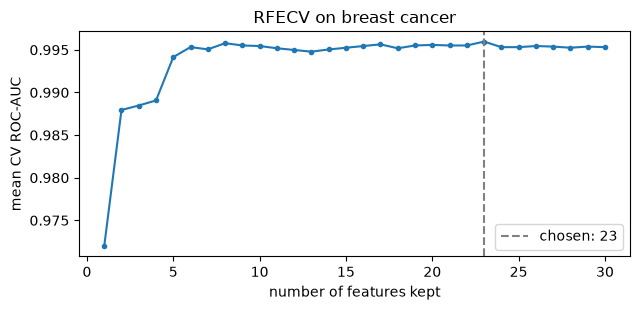

In [33]:
cancer = load_breast_cancer(as_frame=True)
cancer_X, cancer_y = cancer.data, cancer.target
cancer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scaled_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

rfecv = RFECV(scaled_lr, step=1, cv=cancer_cv, scoring="roc_auc", min_features_to_select=1,
              importance_getter="named_steps.logisticregression.coef_").fit(cancer_X, cancer_y)
print(f"RFECV keeps {rfecv.n_features_} of 30 features (best mean CV AUC {rfecv.cv_results_['mean_test_score'].max():.4f})")

start = time.perf_counter()
sfs = SequentialFeatureSelector(scaled_lr, n_features_to_select=5, direction="forward", cv=cancer_cv, scoring="roc_auc", n_jobs=2).fit(cancer_X, cancer_y)
sfs_s = time.perf_counter() - start
start = time.perf_counter()
floating = MlxtendSFS(scaled_lr, k_features=5, forward=True, floating=True, scoring="roc_auc", cv=cancer_cv, n_jobs=2).fit(cancer_X, cancer_y)
floating_s = time.perf_counter() - start
print(f"scikit-learn forward SFS (5 features, {sfs_s:.1f}s): {cancer_X.columns[sfs.get_support()].tolist()}")
print(f"mlxtend floating SFS   (5 features, {floating_s:.1f}s): {list(floating.k_feature_names_)} | CV AUC {floating.k_score_:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(rfecv.cv_results_["n_features"], rfecv.cv_results_["mean_test_score"], marker="o", ms=3)
ax.axvline(rfecv.n_features_, ls="--", color="gray", label=f"chosen: {rfecv.n_features_}")
ax.set(xlabel="number of features kept", ylabel="mean CV ROC-AUC", title="RFECV on breast cancer")
ax.legend()
plt.tight_layout()
plt.show()

**L1 path.** Stronger regularization (smaller `C`) zeroes more coefficients. In scikit-learn 1.8+ the `penalty` argument of `LogisticRegression` is deprecated: use `l1_ratio=1` (pure L1) with a solver that supports it (`liblinear` or `saga`).

In [34]:
l1_rows = []
for C in np.logspace(-2.5, 1, 8):
    l1_model = make_pipeline(StandardScaler(), LogisticRegression(l1_ratio=1.0, solver="liblinear", C=C, max_iter=5000))
    auc = cross_val_score(l1_model, cancer_X, cancer_y, cv=cancer_cv, scoring="roc_auc").mean()
    nonzero = int((l1_model.fit(cancer_X, cancer_y)[-1].coef_ != 0).sum())
    l1_rows.append({"C": C, "non-zero coefficients": nonzero, "CV ROC-AUC": auc})
l1_table = pd.DataFrame(l1_rows)
print(l1_table.round(4).to_string(index=False))

X_sel_train, X_sel_valid, y_sel_train, y_sel_valid = train_test_split(cancer_X, cancer_y, test_size=0.3, stratify=cancer_y, random_state=SEED)
fitted_lr = clone(scaled_lr).fit(X_sel_train, y_sel_train)
perm = permutation_importance(fitted_lr, X_sel_valid, y_sel_valid, scoring="roc_auc", n_repeats=20, random_state=SEED)
perm_series = pd.Series(perm.importances_mean, index=cancer_X.columns).sort_values(ascending=False)
print(f"\npermutation importance (AUC drop on held-out rows), top 5: {perm_series.head(5).round(4).to_dict()}")
print(f"features whose shuffling changes AUC by < 0.001: {(perm_series.abs() < 0.001).sum()} of 30 — correlated twins cover for each other")

      C  non-zero coefficients  CV ROC-AUC
 0.0032                      0      0.5000
 0.0100                      4      0.9845
 0.0316                      4      0.9916
 0.1000                      8      0.9939
 0.3162                     11      0.9953
 1.0000                     16      0.9958
 3.1623                     20      0.9914
10.0000                     24      0.9875



permutation importance (AUC drop on held-out rows), top 5: {'area error': 0.0088, 'radius error': 0.008, 'worst texture': 0.0071, 'worst concave points': 0.0027, 'worst radius': 0.0026}
features whose shuffling changes AUC by < 0.001: 17 of 30 — correlated twins cover for each other


Now a fair comparison: **every selector inside the pipeline**, so each CV fold selects on its own training rows.

In [35]:
selectors = {
    "all 30 features": "passthrough",
    "SelectKBest(f_classif, k=10)": SelectKBest(f_classif, k=10),
    "RFECV (logistic regression)": RFECV(LogisticRegression(max_iter=5000), step=1, cv=StratifiedKFold(5, shuffle=True, random_state=1), scoring="roc_auc"),
    "mlxtend floating SFS (k=5)": MlxtendSFS(LogisticRegression(max_iter=5000), k_features=5, floating=True, scoring="roc_auc",
                                             cv=StratifiedKFold(5, shuffle=True, random_state=1)),
    "L1 logistic (C=0.1) + SelectFromModel": SelectFromModel(LogisticRegression(l1_ratio=1.0, solver="liblinear", C=0.1)),
    "random forest importance > median": SelectFromModel(RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=4), threshold="median"),
}
selection_rows = {}
for name, selector in selectors.items():
    pipe = make_pipeline(StandardScaler(), selector, LogisticRegression(max_iter=5000))
    scores = cross_val_score(pipe, cancer_X, cancer_y, cv=cancer_cv, scoring="roc_auc")
    fitted = clone(pipe).fit(cancer_X, cancer_y)
    n_kept = int(fitted[:-1].transform(cancer_X.iloc[:1]).shape[1])          # scaler + selector, everything except the model
    selection_rows[name] = {"CV ROC-AUC (selection inside)": scores.mean(), "std": scores.std(), "features kept (full fit)": n_kept}
selection_table = pd.DataFrame(selection_rows).T
print(selection_table.round(4))
print(f"\nall features: {selection_table.iloc[0, 0]:.4f}; best: {selection_table.iloc[:, 0].idxmax()} ({selection_table.iloc[:, 0].max():.4f}); "
      f"smallest model: {selection_table['features kept (full fit)'].idxmin()} "
      f"with {int(selection_table['features kept (full fit)'].min())} features at AUC {selection_table.loc[selection_table['features kept (full fit)'].idxmin(), 'CV ROC-AUC (selection inside)']:.4f}")

                                       CV ROC-AUC (selection inside)     std  features kept (full fit)
all 30 features                                               0.9953  0.0053                      30.0
SelectKBest(f_classif, k=10)                                  0.9893  0.0087                      10.0
RFECV (logistic regression)                                   0.9954  0.0052                      23.0
mlxtend floating SFS (k=5)                                    0.9948  0.0036                       5.0
L1 logistic (C=0.1) + SelectFromModel                         0.9958  0.0042                       8.0
random forest importance > median                             0.9952  0.0042                      15.0

all features: 0.9953; best: L1 logistic (C=0.1) + SelectFromModel (0.9958); smallest model: mlxtend floating SFS (k=5) with 5 features at AUC 0.9948


On a clean dataset with a well-regularized model, selection doesn't raise accuracy much; its value is a **smaller, cheaper, more explainable** model at almost the same score. That's typical: selection rarely rescues a good model, but it can make it much simpler.

### ✍️ Your Turn

How many features does `SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=SEED), threshold="median")` keep on `cancer_X`? Store the count in `n_kept_median`.

In [36]:
n_kept_median = None  # TODO: your code here
check("n_kept_median", n_kept_median, 15, hint="Fit it, then selector.get_support().sum(). 'median' keeps features whose importance is ≥ the median importance.")

⏳ n_kept_median: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=SEED), threshold="median").fit(cancer_X, cancer_y)
n_kept_median = int(selector.get_support().sum())
check("n_kept_median", n_kept_median, 15)
```

With 30 distinct importances, half of them are at or above the median. Use `threshold="1.25*mean"` or `max_features=k` for other rules.
</details>

> 💡 **Interview angle:** "Filter vs wrapper vs embedded feature selection?" — filters score features independently (fast, ignore interactions); wrappers search subsets with a model and CV (RFE, SFS: expensive, can overfit the selection); embedded methods select during training (L1, tree importances). Whatever you use, it goes inside the cross-validation pipeline, and correlated features make any selected set unstable.

## 11. Selection Must Live Inside Cross-Validation 🔴

[Scikit-Learn, Section 4](02_Scikit_Learn.ipynb) showed that selecting features on all rows before cross-validation inflates accuracy on pure noise. Two deeper questions interviewers like:

1. **How bad does it get?** The more candidate features you screen, the more "lucky" noise columns look predictive, so the leak grows with the number of candidates.
2. **Does it matter on real data with real signal?** Yes: the optimism is smaller but it makes you trust noise features and pick the wrong model.

**Experiment 1 (controlled synthetic data, on purpose):** 100 rows, random labels, 100 / 1,000 / 10,000 pure-noise features, keep the 10 best by ANOVA F, 5 random seeds each. Chance is 50%.

           leaky CV accuracy        honest CV accuracy       
                        mean    std               mean    std
candidates                                                   
100                    0.696  0.036              0.512  0.059
1000                   0.770  0.023              0.542  0.052
10000                  0.826  0.044              0.514  0.063


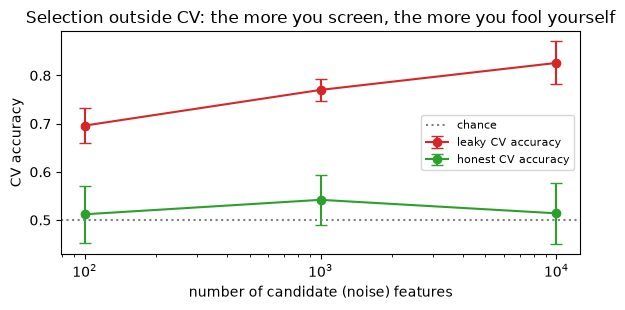

In [37]:
bias_rows = []
for n_candidates in [100, 1_000, 10_000]:
    for seed in range(5):
        noise_rng = np.random.default_rng(seed)
        X_noise, y_noise = noise_rng.normal(size=(100, n_candidates)), noise_rng.integers(0, 2, size=100)
        folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
        chosen = SelectKBest(f_classif, k=10).fit(X_noise, y_noise).transform(X_noise)       # ❌ looked at every row's label
        leaky = cross_val_score(LogisticRegression(), chosen, y_noise, cv=folds).mean()
        honest = cross_val_score(make_pipeline(SelectKBest(f_classif, k=10), LogisticRegression()), X_noise, y_noise, cv=folds).mean()
        bias_rows.append({"candidates": n_candidates, "seed": seed, "leaky CV accuracy": leaky, "honest CV accuracy": honest})
bias = pd.DataFrame(bias_rows).groupby("candidates")[["leaky CV accuracy", "honest CV accuracy"]].agg(["mean", "std"])
print(bias.round(3))

fig, ax = plt.subplots(figsize=(6, 3.2))
for col, color in [("leaky CV accuracy", "tab:red"), ("honest CV accuracy", "tab:green")]:
    ax.errorbar(bias.index, bias[(col, "mean")], yerr=bias[(col, "std")], marker="o", capsize=4, color=color, label=col)
ax.axhline(0.5, ls=":", color="gray", label="chance")
ax.set(xscale="log", xlabel="number of candidate (noise) features", ylabel="CV accuracy", title="Selection outside CV: the more you screen, the more you fool yourself")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Experiment 2 (real data + noise):** selection bias bites hardest with **few rows and many candidate features** (think genomics, or a small pilot dataset with thousands of logged signals). We train on 200 randomly chosen Titanic passengers, add 5,000 random columns to their 10 real columns, keep `SelectKBest(k=20)`, and use the other 1,109 passengers as a large test set that reveals the truth. Repeated for 5 random samples.

In [38]:
titanic_base = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), TITANIC_NUM),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore", sparse_output=False)), TITANIC_CAT),
])
small_sample_rows = []
for seed in range(5):
    train_idx, test_idx = train_test_split(np.arange(len(titanic)), train_size=200, stratify=titanic_y, random_state=seed)
    base_train = titanic_base.fit_transform(titanic.iloc[train_idx])           # fitted on the 200 training passengers only
    base_test = titanic_base.transform(titanic.iloc[test_idx])
    noise_rng = np.random.default_rng(seed)
    X_small = np.hstack([base_train, noise_rng.normal(size=(len(train_idx), 5_000))])
    X_large_test = np.hstack([base_test, noise_rng.normal(size=(len(test_idx), 5_000))])
    y_small, y_large_test = titanic_y.to_numpy()[train_idx], titanic_y.to_numpy()[test_idx]
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    leaky_selector = SelectKBest(f_classif, k=20).fit(X_small, y_small)             # ❌ saw every training row's label
    leaky_cv = cross_val_score(LogisticRegression(max_iter=2000), leaky_selector.transform(X_small), y_small, cv=folds, scoring="roc_auc").mean()
    honest_pipe = make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=2000))
    honest_cv = cross_val_score(honest_pipe, X_small, y_small, cv=folds, scoring="roc_auc").mean()
    test_auc = roc_auc_score(y_large_test, honest_pipe.fit(X_small, y_small).predict_proba(X_large_test)[:, 1])
    small_sample_rows.append({"sample": seed, "noise columns among the 20 selected": int(leaky_selector.get_support()[base_train.shape[1]:].sum()),
                              "leaky CV AUC": leaky_cv, "honest CV AUC": honest_cv, "test AUC (1,109 passengers)": test_auc})
    del X_small, X_large_test
small_sample = pd.DataFrame(small_sample_rows).set_index("sample")
print(small_sample.round(3))
avg = small_sample.mean()
print(f"\naverage: leaky CV {avg['leaky CV AUC']:.3f} | honest CV {avg['honest CV AUC']:.3f} | test {avg['test AUC (1,109 passengers)']:.3f} → "
      f"the leaky estimate is off by {avg['leaky CV AUC'] - avg['test AUC (1,109 passengers)']:+.3f}, "
      f"the honest one by {avg['honest CV AUC'] - avg['test AUC (1,109 passengers)']:+.3f}")

        noise columns among the 20 selected  leaky CV AUC  honest CV AUC  test AUC (1,109 passengers)
sample                                                                                               
0                                        16         0.922          0.671                        0.646
1                                        16         0.942          0.714                        0.690
2                                        16         0.929          0.668                        0.715
3                                        15         0.914          0.697                        0.721
4                                        16         0.925          0.615                        0.698

average: leaky CV 0.926 | honest CV 0.673 | test 0.694 → the leaky estimate is off by +0.232, the honest one by -0.021


The same rule applies to **every** data-dependent step: scaling, imputation, encoding, target encoding, PCA, resampling ([next notebook](17_Imbalanced_Data_and_Model_Evaluation.ipynb)), and hyperparameter search. And when a selector tunes itself with internal CV (`RFECV`, `SequentialFeatureSelector`), reporting *its* best score is optimistic too: wrap it in an outer CV (nested CV) or check a held-out set.

> 💡 **Interview angle:** "You selected the top 20 of 10,000 genes and got 95% CV accuracy. What's wrong?" — the selection saw every row's label, so the CV folds aren't independent of the choice (Ambroise & McLachlan, 2002). Put selection inside the pipeline (or use nested CV) and expect the honest estimate to be far lower — on pure noise it drops back to chance.

## 12. Correlated Features and Multicollinearity 🟡

**Multicollinearity** = some features are (nearly) linear combinations of others. It doesn't necessarily hurt **predictions**, but it makes **coefficients** unstable: the model can trade weight between twins almost freely, so small data changes swing the coefficients, standard errors explode, and signs can flip.

The **variance inflation factor** for feature $j$ regresses it on all other features:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

VIF = 1 means no collinearity; above 5–10 is the usual warning sign; ∞ means an exact linear combination. In Ames, `GrLivArea` is *exactly* `1stFlrSF + 2ndFlrSF + LowQualFinSF`.

In [39]:
identity_share = (ames_X["1stFlrSF"] + ames_X["2ndFlrSF"] + ames_X["LowQualFinSF"] == ames_X["GrLivArea"]).mean()
print(f"GrLivArea == 1stFlrSF + 2ndFlrSF + LowQualFinSF for {identity_share:.1%} of training houses")


def vif_table(frame):
    design = add_constant(frame.astype(float))
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        with np.errstate(divide="ignore"):
            values = {col: variance_inflation_factor(design.to_numpy(), i) for i, col in enumerate(design.columns) if col != "const"}
    return pd.Series(values, name="VIF"), len(caught)


collinear_cols = ["GrLivArea", "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "TotRmsAbvGrd", "GarageCars", "GarageArea", "OverallQual", "YearBuilt"]
vif_exact, n_warnings = vif_table(ames_X[collinear_cols])
vif_clean, _ = vif_table(ames_X[["GrLivArea", "TotRmsAbvGrd", "GarageCars", "GarageArea", "OverallQual", "YearBuilt"]])
print(pd.DataFrame({"VIF with the floor areas": vif_exact, "VIF after dropping them": vif_clean}).round(2).to_string())
print(f"(statsmodels raised {n_warnings} rank-deficiency warnings for the first design, as it should)")

GrLivArea == 1stFlrSF + 2ndFlrSF + LowQualFinSF for 100.0% of training houses
              VIF with the floor areas  VIF after dropping them
1stFlrSF                    1.0008e+15                      NaN
2ndFlrSF                    1.0008e+15                      NaN
GarageArea                  4.8900e+00                     4.72
GarageCars                  5.1600e+00                     5.13
GrLivArea                   1.0008e+15                     4.17
LowQualFinSF                1.0008e+15                      NaN
OverallQual                 2.3700e+00                     2.36
TotRmsAbvGrd                3.2200e+00                     3.19
YearBuilt                   1.8000e+00                     1.76
(statsmodels raised 14 rank-deficiency warnings for the first design, as it should)


Now the consequence. We refit ordinary least squares on 300 bootstrap resamples of the training houses (log price) and look at how much the `GarageCars` coefficient and the predictions for five fixed houses move, with and without its twin `GarageArea` (correlation shown below).

corr(GarageCars, GarageArea) = 0.883
                                      GarageCars coef mean  GarageCars coef std  mean std of 5 predictions (log $)
GarageCars + OverallQual + GrLivArea                0.1410               0.0122                             0.0130
+ GarageArea (its twin)                             0.1043               0.0349                             0.0161

adding the twin multiplies the coefficient's std by 2.9× but the prediction std only by 1.24×


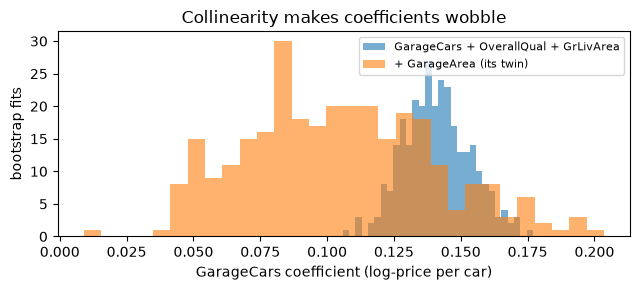

In [40]:
boot_rng = np.random.default_rng(SEED)
fixed_houses = ames_X.iloc[:5]
designs = {
    "GarageCars + OverallQual + GrLivArea": ["GarageCars", "OverallQual", "GrLivArea"],
    "+ GarageArea (its twin)": ["GarageCars", "GarageArea", "OverallQual", "GrLivArea"],
}
boot_coefs, boot_rows = {}, {}
log_price = np.log(ames_y)
for name, cols in designs.items():
    coefs, preds = [], []
    for _ in range(300):
        idx = boot_rng.integers(0, len(ames_X), len(ames_X))
        ols = LinearRegression().fit(ames_X[cols].iloc[idx], log_price.iloc[idx])
        coefs.append(ols.coef_[0])
        preds.append(ols.predict(fixed_houses[cols]))
    boot_coefs[name] = np.array(coefs)
    boot_rows[name] = {"GarageCars coef mean": np.mean(coefs), "GarageCars coef std": np.std(coefs),
                       "mean std of 5 predictions (log $)": np.std(preds, axis=0).mean()}
boot_table = pd.DataFrame(boot_rows).T
print(f"corr(GarageCars, GarageArea) = {ames_X['GarageCars'].corr(ames_X['GarageArea']):.3f}")
print(boot_table.round(4))
names = list(designs)
print(f"\nadding the twin multiplies the coefficient's std by {boot_table.iloc[1, 1] / boot_table.iloc[0, 1]:.1f}× "
      f"but the prediction std only by {boot_table.iloc[1, 2] / boot_table.iloc[0, 2]:.2f}×")

fig, ax = plt.subplots(figsize=(6.5, 3))
for name in names:
    ax.hist(boot_coefs[name], bins=30, alpha=0.6, label=name)
ax.set(xlabel="GarageCars coefficient (log-price per car)", ylabel="bootstrap fits", title="Collinearity makes coefficients wobble")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

What to do: if you only need **predictions**, regularization (Ridge) is usually enough. If you need to **interpret coefficients**, drop or combine twins (e.g. keep `GarageCars`, or build one "garage size" feature), use VIF to find them, or report grouped importances.

### ✍️ Your Turn

Regressing a feature on all the others gives $R^2 = 0.8$. Compute its VIF and store it in `vif_value`.

In [41]:
vif_value = None  # TODO: your code here
check("vif_value", vif_value, 5.0, hint="1 / (1 - R²)")

⏳ vif_value: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
vif_value = 1 / (1 - 0.8)
check("vif_value", vif_value, 5.0)
```

The variance of that coefficient is 5× larger than it would be if the feature were uncorrelated with the others; its standard error is √5 ≈ 2.2× larger.
</details>

> 💡 **Interview angle:** "Does multicollinearity hurt a model?" — for prediction, usually little (especially with regularization); for inference, a lot: coefficients get large variances, unstable signs and unreliable p-values. Detect with VIF (> 5–10) or a correlation matrix; fix by dropping/combining features, Ridge, or PCA. It also makes permutation importance and feature selection unstable.

## 13. Production Pipelines and Custom Transformers 🟡

[Scikit-Learn, Section 13](02_Scikit_Learn.ipynb) introduced custom transformers. Here are the production details that trip people up:

- **`make_column_selector`** picks columns by dtype *at fit time*, so new columns are handled automatically. With pandas 3, text columns have the new `str` dtype: select them with `dtype_include=["object", "string"]` or `dtype_exclude="number"` (Pitfall 2 shows the old `object` spelling).
- **`set_output(transform="pandas")`** returns DataFrames with real column names; `get_feature_names_out()` gives the same names as an array, so importances and coefficients stay readable.
- **`FunctionTransformer`** wraps a stateless function; pass `feature_names_out` so names survive.
- A custom **`BaseEstimator, TransformerMixin`** class is needed when something is *learned* in `fit`. Use `validate_data` for input checks and run `check_estimator` to test it against scikit-learn's API contract.

In [42]:
selector_prep = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), make_column_selector(dtype_include="number")),
    ("text", make_pipeline(SimpleImputer(strategy="constant", fill_value="None"),
                           OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False)),
     make_column_selector(dtype_exclude="number")),
]).set_output(transform="pandas")
prepared = selector_prep.fit_transform(ames_X)
print(f"{ames_X.shape[1]} raw columns → {prepared.shape[1]} model columns; the text selector found "
      f"{len(selector_prep.transformers_[1][2])} columns")
print("sample names:", prepared.columns[[0, 1, 36, 37, -1]].tolist())


def ratio_features(frame):
    return pd.DataFrame({"lot_per_living_area": frame["LotArea"] / frame["GrLivArea"],
                         "garage_area_per_car": frame["GarageArea"] / frame["GarageCars"].where(frame["GarageCars"] > 0)}, index=frame.index)


ratio_tf = FunctionTransformer(ratio_features, feature_names_out=lambda transformer, names: np.array(["lot_per_living_area", "garage_area_per_car"]))
print(ratio_tf.fit(ames_X).get_feature_names_out().tolist(), "|", ratio_tf.transform(ames_X.head(2)).round(2).to_dict("records"))

79 raw columns → 253 model columns; the text selector found 43 columns
sample names: ['num__MSSubClass', 'num__LotFrontage', 'text__MSZoning_FV', 'text__MSZoning_RH', 'text__SaleCondition_infrequent_sklearn']
['lot_per_living_area', 'garage_area_per_car'] | [{'lot_per_living_area': 6.39, 'garage_area_per_car': 294.0}, {'lot_per_living_area': 4.99, 'garage_area_per_car': 190.0}]


In [43]:
class QuantileClipper(TransformerMixin, BaseEstimator):
    """Clip each numeric column to quantiles learned on the training rows (winsorizing). NaN passes through."""

    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = validate_data(self, X, dtype="numeric", ensure_all_finite="allow-nan")
        self.lower_bounds_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, reset=False, dtype="numeric", ensure_all_finite="allow-nan")
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self)
        return np.asarray(getattr(self, "feature_names_in_", [f"x{i}" for i in range(self.n_features_in_)]), dtype=object)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.input_tags.allow_nan = True
        return tags


results = []
check_estimator(QuantileClipper(), on_skip=None, on_fail=None, callback=lambda **info: results.append((info["check_name"], info["status"])))
status_counts = pd.Series([status for _, status in results]).value_counts().to_dict()
print(f"check_estimator on QuantileClipper: {status_counts} | not passed: {[name for name, status in results if status != 'passed']}")

clip_search = GridSearchCV(
    log_target(make_pipeline(SimpleImputer(strategy="median"), QuantileClipper(), StandardScaler(), RidgeCV(alphas=ALPHAS))),
    {"regressor__quantileclipper__upper": [0.95, 0.99, 1.0]}, cv=ames_cv, scoring="neg_root_mean_squared_error",
).fit(ames_num, ames_y)
print("GridSearchCV tuned our transformer:", clip_search.best_params_, f"CV RMSE ${-clip_search.best_score_:,.0f}",
      "| all:", dict(zip(clip_search.cv_results_["param_regressor__quantileclipper__upper"], (-clip_search.cv_results_["mean_test_score"]).round(0))))

check_estimator on QuantileClipper: {'passed': 45, 'skipped': 1} | not passed: ['check_array_api_input']


GridSearchCV tuned our transformer: {'regressor__quantileclipper__upper': 0.99} CV RMSE $30,128 | all: {np.float64(0.95): np.float64(30736.0), np.float64(0.99): np.float64(30128.0), np.float64(1.0): np.float64(34870.0)}


### ✍️ Your Turn

Use `make_column_selector(dtype_include="number")` on the three-column `mini_ames` frame and store the list of selected column names in `numeric_names`.

In [44]:
mini_ames = ames_X[["LotArea", "Street", "OverallQual"]]
numeric_names = None  # TODO: your code here
check("numeric_names", numeric_names, ["LotArea", "OverallQual"], hint="make_column_selector(dtype_include='number')(mini_ames)")

⏳ numeric_names: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mini_ames = ames_X[["LotArea", "Street", "OverallQual"]]
numeric_names = make_column_selector(dtype_include="number")(mini_ames)
check("numeric_names", numeric_names, ["LotArea", "OverallQual"])
```

The selector is a callable that returns column names for a DataFrame; inside a `ColumnTransformer` it runs at `fit` time. `make_column_selector(pattern="SF$")` selects by name with a regular expression.
</details>

> 💡 **Interview angle:** "How do you make feature engineering reproducible between training and serving?" — put every step in one fitted `Pipeline`/`ColumnTransformer` (no ad-hoc pandas code at serving time), handle unknown categories and NaN explicitly, keep feature names with `set_output`/`get_feature_names_out`, test custom transformers with `check_estimator`, and version the fitted pipeline together with the model.

## 🔧 Build It From Scratch

### Part A — A cross-fitted, smoothed target encoder

`TargetEncoder.fit_transform(X, y)` for a binary or continuous target computes, **for each column separately**:

1. Split the rows with the `cv` splitter. For each fold, use only the *other* folds' rows ("fold-train").
2. On fold-train, for every level $c$: count $n_c$, mean $\bar y_c$, and population variance $\sigma_c^2$ of the target; also the fold-train mean $\bar y$ and variance $\sigma^2$.
3. Shrink: with a number `smooth` = $m$, $\text{enc}(c) = \frac{n_c \bar y_c + m \bar y}{n_c + m}$; with `smooth="auto"`, $\lambda_c = \frac{n_c \sigma^2}{n_c \sigma^2 + \sigma_c^2}$ and $\text{enc}(c) = \lambda_c \bar y_c + (1-\lambda_c)\bar y$.
4. Encode the held-out fold's rows; a level absent from fold-train gets $\bar y$. Missing values (NaN) are a level of their own.

`transform` on new data uses the same formulas fitted on **all** training rows (stored in `encodings_`).

In [45]:
def encoding_from_stats(level_values, y, smooth):
    """Map level → shrunk mean, following scikit-learn's formulas."""
    stats_frame = pd.DataFrame({"level": level_values, "y": y}).groupby("level")["y"].agg(["sum", "count", "var"])
    y_mean, y_var = y.mean(), y.var()                                  # population variance (ddof=0), like NumPy
    if smooth == "auto":
        within_var = stats_frame["var"].fillna(0.0) * (stats_frame["count"] - 1) / stats_frame["count"]   # pandas var is ddof=1 → convert
        lam = y_var * stats_frame["count"] / (y_var * stats_frame["count"] + within_var)
        encoding = lam * stats_frame["sum"] / stats_frame["count"] + (1 - lam) * y_mean
    else:
        encoding = (stats_frame["sum"] + smooth * y_mean) / (stats_frame["count"] + smooth)
    return encoding, y_mean


def scratch_target_encode(X, y, cv, smooth="auto"):
    """Cross-fitted target encoding for binary (0/1) or continuous y — the fit_transform path."""
    y = np.asarray(y, dtype=float)
    out = np.empty(X.shape, dtype=float)
    for j, col in enumerate(X.columns):
        levels = X[col].astype(object).fillna("__missing__").to_numpy()
        for train_idx, held_idx in cv.split(X, y):
            encoding, fold_mean = encoding_from_stats(levels[train_idx], y[train_idx], smooth)
            out[held_idx, j] = pd.Series(levels[held_idx]).map(encoding).fillna(fold_mean).to_numpy()
    return out


# Binary target: Adult income with three categorical columns (two contain NaN)
adult_enc_cols = ["native-country", "occupation", "education"]
adult_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for smooth in ["auto", 10.0]:
    ours = scratch_target_encode(adult.data[adult_enc_cols], adult_y, adult_folds, smooth)
    ref = TargetEncoder(smooth=smooth, cv=adult_folds).fit_transform(adult.data[adult_enc_cols], adult_y)
    assert np.allclose(ours, ref, atol=1e-12), np.abs(ours - ref).max()
    print(f"✅ binary target, smooth={smooth!r}: scratch fit_transform matches TargetEncoder on {ours.shape[0]:,} rows × {ours.shape[1]} columns "
          f"(max abs diff {np.abs(ours - ref).max():.1e})")

# Continuous target: log sale price in Ames, plain KFold
ames_folds = KFold(n_splits=5, shuffle=True, random_state=SEED)
ours = scratch_target_encode(ames_X[["Neighborhood", "MSZoning", "GarageType"]], np.log(ames_y), ames_folds, "auto")
continuous_encoder = TargetEncoder(cv=ames_folds, target_type="continuous")
ref = continuous_encoder.fit_transform(ames_X[["Neighborhood", "MSZoning", "GarageType"]], np.log(ames_y))
assert np.allclose(ours, ref, atol=1e-12)
full_encoding, _ = encoding_from_stats(ames_X["Neighborhood"].to_numpy(), np.log(ames_y).to_numpy(), "auto")
assert np.allclose(full_encoding.loc[continuous_encoder.categories_[0]].to_numpy(), continuous_encoder.encodings_[0])
print("✅ continuous target: cross-fitted training encodings and the full-data encodings_ used by transform both match")

✅ binary target, smooth='auto': scratch fit_transform matches TargetEncoder on 48,842 rows × 3 columns (max abs diff 2.2e-16)
✅ binary target, smooth=10.0: scratch fit_transform matches TargetEncoder on 48,842 rows × 3 columns (max abs diff 2.8e-17)
✅ continuous target: cross-fitted training encodings and the full-data encodings_ used by transform both match


### Part B — Mutual information for discrete features

$I(X;Y) = \sum_{x,y} p(x,y)\log\frac{p(x,y)}{p(x)p(y)}$ from a contingency table of counts, in nats. We also check the identity $I(X;Y) = H(Y) - H(Y\mid X)$.

In [46]:
def mutual_information_discrete(x, y):
    counts = pd.crosstab(pd.Series(np.asarray(x)), pd.Series(np.asarray(y))).to_numpy(dtype=float)
    joint = counts / counts.sum()                      # a new array: pandas 3 (Copy-on-Write) hands out read-only views
    p_x, p_y = joint.sum(axis=1, keepdims=True), joint.sum(axis=0, keepdims=True)
    nonzero = joint > 0
    return float(np.sum(joint[nonzero] * np.log(joint[nonzero] / (p_x @ p_y)[nonzero])))


def entropy(labels):
    p = pd.Series(np.asarray(labels)).value_counts(normalize=True).to_numpy()
    return float(-np.sum(p * np.log(p)))


income = np.where(adult_y == 1, ">50K", "<=50K")
for col in ["education", "occupation", "relationship", "native-country"]:
    levels = adult.data[col].astype(object).fillna("missing").to_numpy()
    ours = mutual_information_discrete(levels, income)
    conditional_entropy = sum((levels == level).mean() * entropy(income[levels == level]) for level in np.unique(levels))
    assert np.isclose(ours, mutual_info_score(levels, income))
    assert np.isclose(ours, entropy(income) - conditional_entropy)
    print(f"✅ MI(income; {col:14s}) = {ours:.4f} nats — matches mutual_info_score and H(Y) − H(Y|X)")

title = add_titanic_text_features(titanic)["title"].to_numpy()
assert np.isclose(mutual_information_discrete(title, titanic_y), mutual_info_score(title, titanic_y))
assert np.isclose(mutual_information_discrete(title, titanic_y),
                  mutual_info_classif(OrdinalEncoder().fit_transform(title.reshape(-1, 1)), titanic_y, discrete_features=True)[0])
print(f"✅ MI(survived; title) = {mutual_information_discrete(title, titanic_y):.4f} nats — also matches mutual_info_classif(discrete_features=True)")

✅ MI(income; education     ) = 0.0638 nats — matches mutual_info_score and H(Y) − H(Y|X)


✅ MI(income; occupation    ) = 0.0637 nats — matches mutual_info_score and H(Y) − H(Y|X)
✅ MI(income; relationship  ) = 0.1147 nats — matches mutual_info_score and H(Y) − H(Y|X)
✅ MI(income; native-country) = 0.0057 nats — matches mutual_info_score and H(Y) − H(Y|X)
✅ MI(survived; title) = 0.1565 nats — also matches mutual_info_classif(discrete_features=True)


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Features recorded after the outcome (target leakage)

Titanic's `boat` column is the lifeboat number and `body` is the body identification number. Both were written down *after* the sinking. Including them gives a "brilliant" model that could never be used before the event.

In [47]:
leak_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
leaky_titanic = titanic_X.assign(boat_known=titanic["boat"].notna().astype(int))
leak_model = make_pipeline(ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), TITANIC_NUM + ["cabin_missing", "boat_known"]),
    categorical_steps]), LogisticRegression(max_iter=2000))
clean_model = make_pipeline(ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), TITANIC_NUM + ["cabin_missing"]),
    categorical_steps]), LogisticRegression(max_iter=2000))
leak_acc = cross_val_score(leak_model, leaky_titanic, titanic_y, cv=leak_folds, scoring="accuracy").mean()
clean_acc = cross_val_score(clean_model, titanic_X, titanic_y, cv=leak_folds, scoring="accuracy").mean()
print(f"survival rate when a boat number is recorded: {titanic_y[titanic['boat'].notna()].mean():.1%}")
print(f"❌ with 'boat_known': CV accuracy {leak_acc:.3f}  (too good to be true)")
print(f"✅ only information available before departure: CV accuracy {clean_acc:.3f}")

survival rate when a boat number is recorded: 98.1%
❌ with 'boat_known': CV accuracy 0.976  (too good to be true)
✅ only information available before departure: CV accuracy 0.787


**Rule:** for every feature ask "would I know this value at prediction time?" Suspiciously strong single features are the first thing to audit.

### ❌ Pitfall 2 — Selecting text columns with `dtype_include=object` under pandas 3

pandas 3 stores text in the new `str` dtype. Selecting it with the old `object` spelling still works today but is deprecated, and will silently select **nothing** once the backward-compatibility shim is removed.

In [48]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    old_style = make_column_selector(dtype_include=object)(ames_X)
print(f"❌ dtype_include=object selected {len(old_style)} columns but raised: "
      f"{[f'{type(w.message).__name__}: {str(w.message).split(chr(46))[0]}' for w in caught][:1]}")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    new_style = make_column_selector(dtype_include=["object", "string"])(ames_X)
    exclude_style = make_column_selector(dtype_exclude="number")(ames_X)
print(f"✅ dtype_include=['object', 'string'] → {len(new_style)} columns, dtype_exclude='number' → {len(exclude_style)} columns, "
      f"{len(caught)} warnings | text dtype here: {ames_X['Street'].dtype}")

❌ dtype_include=object selected 43 columns but raised: ["Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified"]
✅ dtype_include=['object', 'string'] → 43 columns, dtype_exclude='number' → 43 columns, 0 warnings | text dtype here: str


### ❌ Pitfall 3 — Box-Cox on a column that contains zeros

In [49]:
try:
    PowerTransformer(method="box-cox").fit(ames_X[["MasVnrArea"]])
except ValueError as err:
    print("❌ ValueError:", err)
yeo = PowerTransformer(method="yeo-johnson").fit(ames_X[["MasVnrArea"]])
print(f"✅ Yeo-Johnson handles zeros: λ = {yeo.lambdas_[0]:.3f}, skew {stats.skew(ames_X['MasVnrArea'], nan_policy='omit'):.2f} → "
      f"{stats.skew(yeo.transform(ames_X[['MasVnrArea']]).ravel(), nan_policy='omit'):.2f} "
      f"({(ames_X['MasVnrArea'] == 0).mean():.0%} of houses have no masonry veneer)")

❌ ValueError: The Box-Cox transformation can only be applied to strictly positive data
✅ Yeo-Johnson handles zeros: λ = -0.214, skew 2.28 → 0.37 (58% of houses have no masonry veneer)


### ❌ Pitfall 4 — `dropna()` on a table with structural missing values

In [50]:
print(f"❌ ames_X.dropna() keeps {len(ames_X.dropna())} of {len(ames_X):,} houses — PoolQC, MiscFeature, Alley and Fence are NaN for almost everyone")
structural = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"]
filled = ames_X.assign(**{col: ames_X[col].fillna("None") for col in structural})
print(f"✅ fill structural NaN with a 'None' level, impute the rest in the pipeline: {len(filled):,} houses kept; "
      f"remaining columns with NaN: {filled.isna().any().sum()}")

❌ ames_X.dropna() keeps 0 of 1,168 houses — PoolQC, MiscFeature, Alley and Fence are NaN for almost everyone
✅ fill structural NaN with a 'None' level, impute the rest in the pipeline: 1,168 houses kept; remaining columns with NaN: 14


### ❌ Pitfall 5 — Adding every interaction to an unregularized model

Degree-2 polynomial features of the 36 numeric Ames columns give 702 columns for ~934 training rows per fold. Ordinary least squares can now fit the training folds perfectly — and falls apart on the validation folds.

In [51]:
poly_steps = [SimpleImputer(strategy="median"), StandardScaler(), PolynomialFeatures(degree=2, include_bias=False), StandardScaler()]
n_poly = make_pipeline(*[clone(s) for s in poly_steps]).fit_transform(ames_num).shape[1]
ols_poly = cv_rmse(make_pipeline(*[clone(s) for s in poly_steps], LinearRegression()), ames_num)
ridge_poly = cv_rmse(make_pipeline(*[clone(s) for s in poly_steps], RidgeCV(alphas=np.logspace(0, 5, 30))), ames_num)
ridge_plain = cv_rmse(make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), RidgeCV(alphas=ALPHAS)), ames_num)
print(f"{n_poly} polynomial columns")
print(f"❌ LinearRegression on all of them: CV RMSE ${ols_poly[0]:,.0f} (fold std ${ols_poly[1]:,.0f})")
print(f"✅ RidgeCV on the same columns:     CV RMSE ${ridge_poly[0]:,.0f} | plain Ridge without interactions ${ridge_plain[0]:,.0f}")

702 polynomial columns
❌ LinearRegression on all of them: CV RMSE $1,042,994 (fold std $998,106)
✅ RidgeCV on the same columns:     CV RMSE $109,674 | plain Ridge without interactions $37,170


Add interactions you have a reason for (like hour × working day in Section 4), and regularize.

## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Frequency encoding without leakage
Learn level frequencies (share of rows) from `train_levels` only, then encode `test_levels`; a level never seen in training gets 0. Store the encoded test values in `test_frequency`.

In [52]:
train_levels = pd.Series(["a", "b", "a", "c", "a"])
test_levels = pd.Series(["a", "c", "d"])
test_frequency = None  # TODO
check("test_frequency", test_frequency, [0.6, 0.2, 0.0], hint="test_levels.map(train_levels.value_counts(normalize=True)).fillna(0)")

⏳ test_frequency: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
train_levels = pd.Series(["a", "b", "a", "c", "a"])
test_levels = pd.Series(["a", "c", "d"])
frequencies = train_levels.value_counts(normalize=True)        # learned from training rows only
test_frequency = test_levels.map(frequencies).fillna(0.0).to_numpy()
check("test_frequency", test_frequency, [0.6, 0.2, 0.0])
```
Counting on train + test together would let test rows change the training features: a mild but real leak, and impossible in production where test rows arrive one at a time.
</details>

### 🟢 Exercise 2 — Ordinal encoding with the true order
Encode the kitchen ratings with `OrdinalEncoder` so that `Po < Fa < TA < Gd < Ex` become 0–4. Store the encoded column (shape `(4, 1)`) in `kitchen_codes`.

In [53]:
kitchen = pd.DataFrame({"KitchenQual": ["Gd", "TA", "Ex", "Po"]})
kitchen_codes = None  # TODO
check("kitchen_codes", kitchen_codes, [[3], [2], [4], [0]], hint="OrdinalEncoder(categories=[['Po', 'Fa', 'TA', 'Gd', 'Ex']])")

⏳ kitchen_codes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
kitchen = pd.DataFrame({"KitchenQual": ["Gd", "TA", "Ex", "Po"]})
kitchen_codes = OrdinalEncoder(categories=[["Po", "Fa", "TA", "Gd", "Ex"]]).fit_transform(kitchen)
check("kitchen_codes", kitchen_codes, [[3], [2], [4], [0]])
```
Without `categories=`, the encoder sorts alphabetically (`Ex=0, Gd=1, Po=2, TA=3`), which scrambles the quality order for a linear model.
</details>

### 🟢 Exercise 3 — VIF by regression
Compute the VIF of `"mean radius"` among the three breast-cancer columns in `vif_frame`: regress it on the other two with `LinearRegression`, take $R^2$, and return $1/(1-R^2)$ in `radius_vif`.

In [54]:
vif_frame = cancer_X[["mean radius", "mean texture", "mean perimeter"]]
radius_vif = None  # TODO
check("radius_vif", radius_vif, variance_inflation_factor(add_constant(vif_frame).to_numpy(), 1), rtol=1e-6,
      hint="r2 = LinearRegression().fit(others, target).score(others, target); 1 / (1 - r2)")

⏳ radius_vif: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
vif_frame = cancer_X[["mean radius", "mean texture", "mean perimeter"]]
others, target = vif_frame[["mean texture", "mean perimeter"]], vif_frame["mean radius"]
r2 = LinearRegression().fit(others, target).score(others, target)
radius_vif = 1 / (1 - r2)
check("radius_vif", radius_vif, variance_inflation_factor(add_constant(vif_frame).to_numpy(), 1), rtol=1e-6)
```
The perimeter of a (roughly round) tumour is almost 2π × radius, so R² is close to 1 and the VIF is in the hundreds.
</details>

### 🟡 Exercise 4 — Smoothed target encoding by hand
For the Titanic passengers with a known port of embarkation, compute the smoothed survival encoding of `embarked` with `smooth = 5` using **all** of these rows (the `fit` / `encodings_` path, no cross fitting). Return the three encodings for `C`, `Q`, `S` (alphabetical) in `port_encoding`.

In [55]:
ports = titanic.loc[titanic["embarked"].notna(), ["embarked"]]
port_survival = titanic_y[ports.index].to_numpy()
port_encoding = None  # TODO
check("port_encoding", port_encoding, TargetEncoder(smooth=5.0).fit(ports, port_survival).encodings_[0],
      hint="stats = groupby(embarked) → sum and count of survived; (sum + 5 * global_mean) / (count + 5)")

⏳ port_encoding: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ports = titanic.loc[titanic["embarked"].notna(), ["embarked"]]
port_survival = titanic_y[ports.index].to_numpy()
grouped = pd.Series(port_survival).groupby(ports["embarked"].astype(str).to_numpy()).agg(["sum", "count"]).sort_index()
global_mean = port_survival.mean()
port_encoding = ((grouped["sum"] + 5 * global_mean) / (grouped["count"] + 5)).to_numpy()
check("port_encoding", port_encoding, TargetEncoder(smooth=5.0).fit(ports, port_survival).encodings_[0])
```
With hundreds of passengers per port, smoothing of 5 barely moves the raw means; it matters for levels with a handful of rows.
</details>

### 🟡 Exercise 5 — The χ² score for one binary feature
scikit-learn's `chi2` compares, for each class, the **observed** sum of the feature with the **expected** sum if the feature were independent of the class: $\chi^2 = \sum_{k} \frac{(O_k - E_k)^2}{E_k}$ with $O_k = \sum_{i: y_i = k} x_i$ and $E_k = P(y=k) \cdot \sum_i x_i$. Compute it for `x_flag` and store it in `chi2_by_hand`.

In [56]:
x_flag = (titanic["sex"] == "female").astype(int).to_numpy()
y_survived = titanic_y.to_numpy()
chi2_by_hand = None  # TODO
check("chi2_by_hand", chi2_by_hand, chi2(x_flag.reshape(-1, 1), y_survived)[0][0],
      hint="observed = [x_flag[y_survived == k].sum() for k in (0, 1)]; expected = class shares * x_flag.sum()")

⏳ chi2_by_hand: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_flag = (titanic["sex"] == "female").astype(int).to_numpy()
y_survived = titanic_y.to_numpy()
observed = np.array([x_flag[y_survived == k].sum() for k in (0, 1)])
expected = np.array([(y_survived == k).mean() for k in (0, 1)]) * x_flag.sum()
chi2_by_hand = ((observed - expected) ** 2 / expected).sum()
check("chi2_by_hand", chi2_by_hand, chi2(x_flag.reshape(-1, 1), y_survived)[0][0])
```
Note this "feature-sum" version only uses the cells where the feature is 1, which is why `chi2` needs non-negative features and is usually applied to counts or one-hot columns.
</details>

### 🔴 Exercise 6 — Recursive feature elimination from scratch (interview classic)
Implement `rfe_support(X, y, k)`: start with all columns; repeatedly fit `LogisticRegression(max_iter=5000)` on the remaining columns and remove the **one** column with the smallest absolute coefficient, until `k` remain. Return a boolean mask over the original columns. It must match `RFE(..., n_features_to_select=5, step=1)` on the standardized breast-cancer data.

In [57]:
from sklearn.feature_selection import RFE

cancer_scaled = StandardScaler().fit_transform(cancer_X)


def rfe_support(X, y, k):
    return None  # TODO: return a boolean array of length X.shape[1]


reference_support = RFE(LogisticRegression(max_iter=5000), n_features_to_select=5, step=1).fit(cancer_scaled, cancer_y).support_
check("rfe_support", rfe_support(cancer_scaled, cancer_y, 5), reference_support,
      hint="remaining = list(range(d)); while len(remaining) > k: coef = LogisticRegression(...).fit(X[:, remaining], y).coef_; drop remaining[argmin(|coef|)]")

⏳ rfe_support: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
from sklearn.feature_selection import RFE

cancer_scaled = StandardScaler().fit_transform(cancer_X)


def rfe_support(X, y, k):
    remaining = list(range(X.shape[1]))
    while len(remaining) > k:
        coef = LogisticRegression(max_iter=5000).fit(X[:, remaining], y).coef_
        weakest = int(np.argmin(np.abs(coef).sum(axis=0)))       # sum over classes (one row for a binary problem)
        remaining.pop(weakest)
    support = np.zeros(X.shape[1], dtype=bool)
    support[remaining] = True
    return support


reference_support = RFE(LogisticRegression(max_iter=5000), n_features_to_select=5, step=1).fit(cancer_scaled, cancer_y).support_
check("rfe_support", rfe_support(cancer_scaled, cancer_y, 5), reference_support)
print(cancer_X.columns[rfe_support(cancer_scaled, cancer_y, 5)].tolist())
```
Talking points: standardize first (coefficient size is only comparable on the same scale), refit after every removal (importances change when a correlated twin leaves), `step > 1` trades accuracy for speed, and wrap the whole thing in CV (`RFECV`) or it overfits the selection.
</details>

## 🚀 Mini Project: Ames Feature Engineering Ablation

**Goal:** find out, with numbers, **which feature ideas actually earn their place** in a house-price model. An *ablation study* adds (or removes) one idea at a time while keeping everything else fixed, so each change in error can be credited to that idea.

**Rules:**
- Same model (`RidgeCV`, a linear model that tunes its own regularization inside each training fold), same 5 folds, same training split from Setup.
- Every learned step (imputers, encoders, group medians, selection) lives **inside** the pipeline.
- Choices are made on **CV RMSE**. The locked test set (292 houses) is scored at the end for every row of the table, as an ablation report — it is *not* used to choose.

**Steps:** define the steps → run the ablation → one table with CV score, test score and feature count → computed conclusions → error analysis.

### Step 1 — Define the cumulative feature groups

In [58]:
X_test_ames, y_test_ames = ames_test.drop(columns="SalePrice"), ames_test["SalePrice"]
quality_block = ("quality", make_pipeline(SimpleImputer(strategy="constant", fill_value="None"),
                                          OrdinalEncoder(categories=[QUALITY_ORDER] * len(QUALITY_COLS), handle_unknown="use_encoded_value",
                                                         unknown_value=-1), StandardScaler()), QUALITY_COLS)
nominal_block = ("nominal", make_pipeline(SimpleImputer(strategy="constant", fill_value="None"),
                                          OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10, sparse_output=False)), NOMINAL)
ratio_block = ("ratio", make_pipeline(GroupRatio(), FunctionTransformer(np.log), StandardScaler()), ["Neighborhood", "GrLivArea"])


def ablation_model(log_y=False, log_areas=False, indicators=False, categoricals=False, domain=False, ratio=False, select=False):
    num_cols = NUM_ENG if domain else NUM_RAW
    skewed = [c for c in AREA_COLS if c in num_cols] if log_areas else []
    blocks = [("numeric", make_pipeline(SimpleImputer(strategy="median", add_indicator=indicators), StandardScaler()),
               [c for c in num_cols if c not in skewed])]
    if skewed:
        blocks.append(("skewed", make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                                               StandardScaler()), skewed))
    if categoricals:
        blocks += [quality_block, nominal_block]
    if ratio:
        blocks.append(ratio_block)
    steps = ([FunctionTransformer(add_ames_features)] if domain else []) + [ColumnTransformer([(n, clone(t), c) for n, t, c in blocks])]
    if select:
        steps.append(SelectFromModel(LassoCV(cv=KFold(5, shuffle=True, random_state=SEED), max_iter=50_000, random_state=SEED)))
    pipe = make_pipeline(*steps, RidgeCV(alphas=ALPHAS))
    return log_target(pipe) if log_y else pipe


ablation_steps = {
    "A. numeric columns (baseline)": dict(),
    "B. + log target": dict(log_y=True),
    "C. + log of area columns, missing flags": dict(log_y=True, log_areas=True, indicators=True),
    "D. + quality order + one-hot categories": dict(log_y=True, log_areas=True, indicators=True, categoricals=True),
    "E. + domain features (totals, ages, baths)": dict(log_y=True, log_areas=True, indicators=True, categoricals=True, domain=True),
    "F. + size vs neighbourhood median": dict(log_y=True, log_areas=True, indicators=True, categoricals=True, domain=True, ratio=True),
    "G. + Lasso feature selection": dict(log_y=True, log_areas=True, indicators=True, categoricals=True, domain=True, ratio=True, select=True),
}
print("\n".join(ablation_steps))

A. numeric columns (baseline)
B. + log target
C. + log of area columns, missing flags
D. + quality order + one-hot categories
E. + domain features (totals, ages, baths)
F. + size vs neighbourhood median
G. + Lasso feature selection


### Step 2 — Run the ablation (CV on the training split)

In [59]:
def n_model_features(fitted):
    pipe = fitted.regressor_ if isinstance(fitted, TransformedTargetRegressor) else fitted
    return int(pipe[:-1].transform(X_test_ames.iloc[:2]).shape[1])


ablation_rows, fitted_models = {}, {}
for name, options in ablation_steps.items():
    start = time.perf_counter()
    model = ablation_model(**options)
    cv_mean, cv_std = cv_rmse(model, ames_X)
    fitted_models[name] = clone(model).fit(ames_X, ames_y)
    ablation_rows[name] = {"CV RMSE ($)": cv_mean, "fold std ($)": cv_std, "features": n_model_features(fitted_models[name]),
                           "seconds": time.perf_counter() - start}
    print(f"{name:45s} CV RMSE ${cv_mean:>9,.0f} ± {cv_std:>6,.0f} | {ablation_rows[name]['features']:>3} features")

reference_name = "HistGradientBoosting, raw columns (reference)"
reference = section1_models["HistGradientBoosting · raw columns (reference)"]
ref_cv = cv_rmse(reference, ames_X)
fitted_models[reference_name] = clone(reference).fit(ames_X, ames_y)
ablation_rows[reference_name] = {"CV RMSE ($)": ref_cv[0], "fold std ($)": ref_cv[1], "features": ames_X.shape[1], "seconds": np.nan}

A. numeric columns (baseline)                 CV RMSE $   37,170 ±  6,996 |  36 features
B. + log target                               CV RMSE $   47,211 ± 32,108 |  36 features
C. + log of area columns, missing flags       CV RMSE $   31,975 ±  7,720 |  37 features


D. + quality order + one-hot categories       CV RMSE $   29,825 ±  8,085 | 220 features


E. + domain features (totals, ages, baths)    CV RMSE $   29,994 ±  8,697 | 225 features


F. + size vs neighbourhood median             CV RMSE $   29,624 ±  8,063 | 226 features


G. + Lasso feature selection                  CV RMSE $   28,398 ±  7,146 |  82 features


### Step 3 — One table: CV score, test score, number of features

                                               CV RMSE ($)  fold std ($)  CV gain vs previous step ($)  test RMSE ($)  features
A. numeric columns (baseline)                      37170.0        6996.0                           NaN        37653.0      36.0
B. + log target                                    47211.0       32108.0                      -10041.0        30283.0      36.0
C. + log of area columns, missing flags            31975.0        7720.0                       15237.0        31746.0      37.0
D. + quality order + one-hot categories            29825.0        8085.0                        2150.0        27465.0     220.0
E. + domain features (totals, ages, baths)         29994.0        8697.0                        -169.0        27359.0     225.0
F. + size vs neighbourhood median                  29624.0        8063.0                         371.0        27314.0     226.0
G. + Lasso feature selection                       28398.0        7146.0                        1226.0  

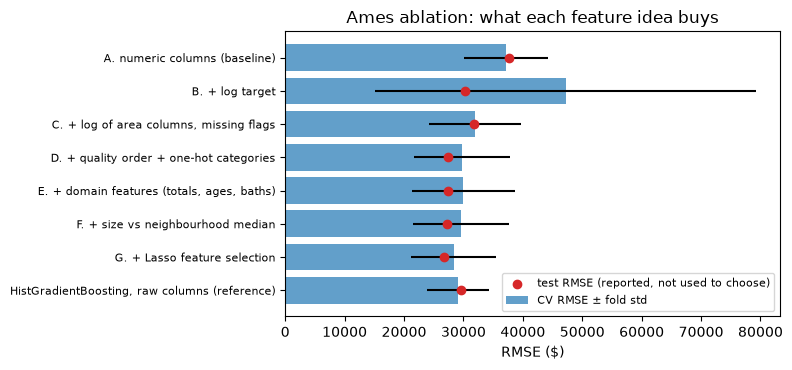

In [60]:
ablation = pd.DataFrame(ablation_rows).T
ablation["CV gain vs previous step ($)"] = -ablation["CV RMSE ($)"].diff()
ablation.loc["A. numeric columns (baseline)", "CV gain vs previous step ($)"] = np.nan
ablation.loc[reference_name, "CV gain vs previous step ($)"] = np.nan
ablation["test RMSE ($)"] = [root_mean_squared_error(y_test_ames, fitted_models[name].predict(X_test_ames)) for name in ablation.index]
print(ablation[["CV RMSE ($)", "fold std ($)", "CV gain vs previous step ($)", "test RMSE ($)", "features"]].round(0).to_string())

fig, ax = plt.subplots(figsize=(8, 3.8))
positions = np.arange(len(ablation))
ax.barh(positions, ablation["CV RMSE ($)"], xerr=ablation["fold std ($)"], color="tab:blue", alpha=0.7, label="CV RMSE ± fold std")
ax.scatter(ablation["test RMSE ($)"], positions, color="tab:red", zorder=3, label="test RMSE (reported, not used to choose)")
ax.set_yticks(positions, ablation.index, fontsize=8)
ax.invert_yaxis()
ax.set(xlabel="RMSE ($)", title="Ames ablation: what each feature idea buys")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Step 4 — Conclusions (computed from the table)

In [61]:
ridge_rows = ablation.drop(index=reference_name)
chosen = ridge_rows["CV RMSE ($)"].idxmin()
biggest_step = ridge_rows["CV gain vs previous step ($)"].idxmax()
selection_delta = ridge_rows.loc["G. + Lasso feature selection", "CV RMSE ($)"] - ridge_rows.loc["F. + size vs neighbourhood median", "CV RMSE ($)"]
selection_std = ridge_rows.loc["F. + size vs neighbourhood median", "fold std ($)"]
features_before = ridge_rows.loc["F. + size vs neighbourhood median", "features"]
features_after = ridge_rows.loc["G. + Lasso feature selection", "features"]
baseline_cv = ridge_rows.loc["A. numeric columns (baseline)", "CV RMSE ($)"]

print(f"1. Chosen by CV: {chosen} — CV RMSE ${ridge_rows.loc[chosen, 'CV RMSE ($)']:,.0f}, "
      f"{1 - ridge_rows.loc[chosen, 'CV RMSE ($)'] / baseline_cv:.0%} below the numeric baseline; test RMSE ${ridge_rows.loc[chosen, 'test RMSE ($)']:,.0f}.")
print(f"2. Biggest single improvement: {biggest_step} (−${ridge_rows.loc[biggest_step, 'CV gain vs previous step ($)']:,.0f} CV RMSE).")
for name, gain in ridge_rows["CV gain vs previous step ($)"].dropna().items():
    verdict = "helps" if gain > ridge_rows.loc[name, "fold std ($)"] / np.sqrt(5) else ("hurts" if gain < -ridge_rows.loc[name, "fold std ($)"] / np.sqrt(5) else "within noise")
    print(f"   {name:45s} {gain:+9,.0f} → {verdict} (vs standard error ≈ ${ridge_rows.loc[name, 'fold std ($)'] / np.sqrt(5):,.0f})")
print(f"3. Lasso selection kept {int(features_after)} of {int(features_before)} features and changed CV RMSE by ${selection_delta:+,.0f} "
      f"({'within' if abs(selection_delta) <= selection_std else 'beyond'} one fold std of ${selection_std:,.0f}): "
      f"{'a much smaller model at about the same accuracy' if abs(selection_delta) <= selection_std else 'selection changed accuracy noticeably'}.")
gap = ridge_rows.loc[chosen, "test RMSE ($)"] - ridge_rows.loc[chosen, "CV RMSE ($)"]
print(f"4. Test vs CV for the chosen model: {gap:+,.0f} → {'consistent' if abs(gap) < 2 * ridge_rows.loc[chosen, 'fold std ($)'] else 'a large gap (check outliers)'} "
      f"given a fold std of ${ridge_rows.loc[chosen, 'fold std ($)']:,.0f}.")
print(f"5. Gradient boosting on raw columns: CV ${ablation.loc[reference_name, 'CV RMSE ($)']:,.0f}, test ${ablation.loc[reference_name, 'test RMSE ($)']:,.0f} — "
      f"the engineered linear model is {'better' if ridge_rows.loc[chosen, 'CV RMSE ($)'] < ablation.loc[reference_name, 'CV RMSE ($)'] else 'still worse'} by CV.")

1. Chosen by CV: G. + Lasso feature selection — CV RMSE $28,398, 24% below the numeric baseline; test RMSE $26,805.
2. Biggest single improvement: C. + log of area columns, missing flags (−$15,237 CV RMSE).
   B. + log target                                 -10,041 → within noise (vs standard error ≈ $14,359)
   C. + log of area columns, missing flags         +15,237 → helps (vs standard error ≈ $3,453)
   D. + quality order + one-hot categories          +2,150 → within noise (vs standard error ≈ $3,616)
   E. + domain features (totals, ages, baths)         -169 → within noise (vs standard error ≈ $3,890)
   F. + size vs neighbourhood median                  +371 → within noise (vs standard error ≈ $3,606)
   G. + Lasso feature selection                     +1,226 → within noise (vs standard error ≈ $3,196)
3. Lasso selection kept 82 of 226 features and changed CV RMSE by $-1,226 (within one fold std of $8,063): a much smaller model at about the same accuracy.
4. Test vs CV for the cho

### Step 5 — Error analysis on the test set

In [62]:
chosen_model = fitted_models[chosen]
analysis = X_test_ames[["Neighborhood", "GrLivArea", "OverallQual", "SaleCondition"]].assign(
    price=y_test_ames, predicted=chosen_model.predict(X_test_ames))
analysis["error"] = analysis["predicted"] - analysis["price"]
analysis["abs % error"] = (analysis["error"].abs() / analysis["price"])
print(analysis.sort_values("abs % error", ascending=False).head(6).round(2).to_string())
by_condition = analysis.groupby("SaleCondition")["abs % error"].agg(["count", "median"]).sort_values("median", ascending=False)
print("\nmedian absolute % error by sale condition:\n", by_condition.round(3).to_string())
print(f"\nhouses above 4,000 sq ft in the test set: {(analysis['GrLivArea'] > 4000).sum()} | "
      f"median abs % error overall {analysis['abs % error'].median():.1%}")

     Neighborhood  GrLivArea  OverallQual SaleCondition   price  predicted      error  abs % error
30         IDOTRR       1317            4        Normal   40000   97182.56   57182.56         1.43
812        IDOTRR       1044            5        Alloca   55993   98298.89   42305.89         0.76
588       ClearCr       1473            5       Partial  143000  249869.42  106869.42         0.75
916        IDOTRR        480            2       Abnorml   35311   59540.96   24229.96         0.69
1432      OldTown        968            4        Normal   64500   99353.29   34853.29         0.54
874       OldTown       1131            5       Abnorml   66500   99002.76   32502.76         0.49

median absolute % error by sale condition:
                count  median
SaleCondition               
Family             2   0.211
Alloca             5   0.121
Abnorml           24   0.088
Partial           27   0.081
Normal           234   0.055

houses above 4,000 sq ft in the test set: 1 | median abs %

**Stretch goals**
1. Add `TargetEncoder` for `Neighborhood` and `Exterior1st` (inside the pipeline) and see whether it beats one-hot for Ridge.
2. Repeat the ablation with `HistGradientBoostingRegressor`: which feature groups still help a tree model? (Expect domain features to matter and log/scaling not to.)
3. The documented Ames outliers (very large partial sales) distort a linear fit: try `HuberRegressor` or removing houses above 4,000 sq ft **from training only**, and report the test effect honestly.
4. Use `RepeatedKFold(5, 3)` to get tighter confidence in the small gains and a paired comparison between steps E and F.

### 🗣️ How to talk about this in an interview
- "I ran an ablation: same Ridge model and folds, adding one feature idea at a time, so each gain is attributable. Logging the skewed area inputs was the big win; the log target alone actually hurt, because the largest houses got exponentially over-predicted in one fold, so feature ideas interact. Several later ideas were within fold noise, and I said so."
- "Every learned step — imputers, encoders, neighbourhood medians, Lasso selection — sits inside one pipeline, so cross-validation refits it per fold and serving uses exactly the same code."
- "Selection kept a fraction of the columns at about the same CV error, which matters for latency and explainability more than for accuracy."
- "I chose by CV and only reported test results; the error analysis showed the worst misses were unusual sales (partial / abnormal conditions), which points to a data-definition fix rather than more features."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Which models need feature scaling, and which don't?**

<details><summary>Show answer</summary>

- **30-second answer:** Distance- and gradient-based models need it: KNN, k-means, SVMs (especially RBF), PCA, regularized linear/logistic regression (the penalty depends on scale) and neural networks. Tree-based models (decision trees, random forests, gradient boosting) don't, because splits are invariant to monotone transformations.
- **Go deeper:** In Section 2 KNN's error moved by thousands of dollars across scalers while HistGradientBoosting didn't change at all. Choose `RobustScaler`/`QuantileTransformer` for heavy outliers, but watch zero-IQR columns (they stay unscaled). Fit the scaler on training folds only.
- **❌ Common wrong answer:** "Always standardize everything; it never hurts" or "random forests need scaling to converge."

</details>

**Q2. How do you choose between one-hot, ordinal, target encoding and hashing?**

<details><summary>Show answer</summary>

- **30-second answer:** One-hot for nominal columns with few levels; ordinal only when levels have a real order (or for trees); target encoding (cross-fitted) or native categorical support for high cardinality; hashing when the vocabulary is huge or unbounded and a fixed width matters. Validate with CV.
- **Go deeper:** One-hot width grows with levels (Amazon: 14k columns); `min_frequency` groups rare levels and `handle_unknown` covers new ones. Hashing has collisions but no vocabulary to store. Target encoding needs smoothing and cross fitting. CatBoost's ordered target statistics and LightGBM's categorical splits avoid manual encoding; scikit-learn's HistGradientBoosting supports at most 255 levels.
- **❌ Common wrong answer:** "Label-encode every categorical as integers for any model."

</details>

**Q3. What exactly leaks in target encoding, and how does cross fitting fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Each training row's own label is included in the average used to encode it; for rare levels the encoding nearly *is* the label, so the model memorizes and fails on new data. Cross fitting encodes each fold using only the other folds, so no row sees its own label; new data is encoded with full-training statistics.
- **Go deeper:** On Amazon the naive encoding gave HistGradientBoosting a near-perfect training AUC and a much lower test AUC; cross-fitted `fit_transform` closed most of the gap, and a leaky pre-encoded CV reported an AUC far above the honest pipeline. Smoothing (`smooth="auto"`, empirical Bayes) shrinks rare levels toward the global mean. In scikit-learn 1.9 pass a splitter to `cv=` for reproducibility.
- **❌ Common wrong answer:** "Smoothing alone prevents leakage" — it reduces it for rare levels but a row's own label is still inside its encoding.

</details>

**Q4. How do you handle missing values?**

<details><summary>Show answer</summary>

- **30-second answer:** First understand why they're missing: structural (no pool → a "None" level or 0), MCAR, MAR or MNAR. Then impute inside the pipeline (median/most frequent, KNN, iterative), add missing indicators when missingness may carry signal, or use models with native NaN support.
- **Go deeper:** Titanic showed missing cabins strongly associated with survival, yet the flag added little because class and fare already captured it — measure, don't assume. `IterativeImputer` is experimental (needs `enable_iterative_imputer`); KNN imputation needs scaling and is O(n²). Never impute using test statistics; don't `dropna()` blindly.
- **❌ Common wrong answer:** "Fill with the mean of the whole dataset before splitting" or "just drop rows with NaN."

</details>

**Q5. Filter vs wrapper vs embedded feature selection?**

<details><summary>Show answer</summary>

- **30-second answer:** Filters score features independently of the model (variance, correlation, mutual information, χ²): fast but blind to interactions and redundancy. Wrappers search subsets using a model's CV score (RFE, sequential selection): better but expensive and prone to overfitting the selection. Embedded methods select during training (L1, tree importances).
- **Go deeper:** Permutation importance on held-out data is model-agnostic but splits credit between correlated features. On breast cancer, selectors kept between 5 and 23 of 30 features at about the same AUC: selection mainly buys simplicity. Always run selection inside CV.
- **❌ Common wrong answer:** "Pick the features most correlated with the target on the whole dataset, then train."

</details>

**Q6. Why must feature selection happen inside cross-validation?**

<details><summary>Show answer</summary>

- **30-second answer:** If you select using all rows, the validation rows' labels influenced which features were kept, so the CV score is optimistically biased — on pure noise it can look far better than chance. Put the selector in the pipeline so each fold selects on its own training rows.
- **Go deeper:** The bias grows with the number of candidates screened (Section 11: leaky accuracy rose with 100 → 10,000 noise features while honest stayed near 50%). Ambroise & McLachlan (2002) documented this "selection bias" in gene-expression studies. Selectors with internal CV (RFECV) still need an outer CV or held-out set for an honest estimate.
- **❌ Common wrong answer:** "Selection doesn't use the model, so it can't leak."

</details>

**Q7. What is multicollinearity? Does it hurt predictions?**

<details><summary>Show answer</summary>

- **30-second answer:** Some features are (nearly) linear combinations of others. Predictions are usually fine, especially with regularization, but coefficients become unstable with inflated variances and possible sign flips, so interpretation and p-values suffer. Detect with VIF = 1/(1−R²) (> 5–10 is a warning).
- **Go deeper:** In Ames, `GrLivArea` equals the sum of the floor areas exactly (infinite VIF). Adding `GarageArea` next to `GarageCars` multiplied the bootstrap std of the `GarageCars` coefficient several times while prediction variability barely changed. Fixes: drop/combine twins, Ridge, PCA, grouped importances.
- **❌ Common wrong answer:** "Correlated features always make a model's predictions worse, so remove them."

</details>

**Q8. Why log-transform a skewed target, and what's the catch?**

<details><summary>Show answer</summary>

- **30-second answer:** Prices and counts often have multiplicative effects and errors that grow with size; a log target makes the relationship more linear and the errors more even. The catch: back-transforming with `exp` estimates something closer to the median than the mean, and it optimizes relative rather than absolute error.
- **Go deeper:** Use `TransformedTargetRegressor(func=np.log, inverse_func=np.exp)` so CV scores are in original units. For an unbiased mean, apply a smearing correction (Duan) or model a distribution (Poisson/Gamma/Tweedie losses). In the mini project (step B) and Section 3, a log target with raw skewed inputs was *worse* in dollars because the biggest houses were exponentially over-predicted; combined with log inputs it helped: transforms interact.
- **❌ Common wrong answer:** "Log the target and report RMSE on the log scale as if it were dollars."

</details>

**Q9. If trees don't need scaling or one-hot, why engineer features for gradient boosting at all?**

<details><summary>Show answer</summary>

- **30-second answer:** Monotone transforms don't help trees, but **new information** and **easier shapes** do: sums and ratios (trees can't add columns), time since an event, aggregates over groups or history, text-derived signals, and good handling of high-cardinality IDs.
- **Go deeper:** Trees approximate `a + b` or `a / b` with many axis-aligned steps, which needs lots of data. Features from other tables or time windows (a user's last-30-day spend) are the biggest wins in industry; they must be computed point-in-time to avoid leakage.
- **❌ Common wrong answer:** "Gradient boosting learns everything, so feature engineering is dead."

</details>

### 💻 Coding

**Q10. Encode an hour-of-day column so that 23:00 and 00:00 are close.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  angle = 2 * np.pi * df["hour"] / 24
  df["hour_sin"], df["hour_cos"] = np.sin(angle), np.cos(angle)
  ```
- **Go deeper:** Keep both coordinates (sine alone is ambiguous). Alternatives: `SplineTransformer(extrapolation="periodic")` with knots spanning 0–24, which can model two daily peaks (it beat sine/cosine in Section 4), or one-hot for 24 levels. Trees can use the raw hour directly.
- **❌ Common wrong answer:** "Scale hour to [0, 1] with MinMaxScaler" — 23:00 and 00:00 are still maximally far apart.

</details>

**Q11. Write a transformer that fills a numeric column with the median of its group, learned without leakage.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  class GroupMedianImputer(TransformerMixin, BaseEstimator):
      def __init__(self, group_col, value_col):
          self.group_col, self.value_col = group_col, value_col
      def fit(self, X, y=None):
          self.medians_ = X.groupby(self.group_col)[self.value_col].median()
          self.global_ = X[self.value_col].median()
          return self
      def transform(self, X):
          fill = X[self.group_col].map(self.medians_).fillna(self.global_)
          return X.assign(**{self.value_col: X[self.value_col].fillna(fill)})
  ```
- **Go deeper:** `__init__` only stores parameters (so `clone`/`GridSearchCV` work), statistics end with `_` and are learned in `fit`, unseen groups get a fallback, and the class goes inside the pipeline. Test with `check_estimator` for array-based transformers.
- **❌ Common wrong answer:** Computing `df.groupby(...).transform("median")` on the full dataset before splitting.

</details>

### 🐛 Debugging Scenarios

**Q12. Your churn model scored 0.97 AUC offline but 0.70 in production. The best feature is `days_since_last_contact`. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage or training–serving skew: was the feature computed *after* the churn event (e.g. contact by the retention team once the customer left), or with a different definition/time window in production? Rebuild the feature point-in-time and compare offline and online feature distributions.
- **Go deeper:** Audit suspiciously strong single features (like Titanic's `boat`), check time-based splits instead of random ones, log serving features and compare with training features, and use a feature store with point-in-time joins. Also check target/group aggregates computed on the full history.
- **❌ Common wrong answer:** "The production data drifted; retrain more often."

</details>

**Q13. A deployed pipeline crashes with `ValueError: Found unknown categories ['NewCity'] in column 0 during transform`. Fix it properly.**

<details><summary>Show answer</summary>

- **30-second answer:** The `OneHotEncoder` uses the default `handle_unknown="error"`. Use `handle_unknown="infrequent_if_exist"` with `min_frequency` (new and rare levels share a column) or `"ignore"` (all zeros), and add monitoring for the rate of unknown levels.
- **Go deeper:** For ordinal encoding use `handle_unknown="use_encoded_value", unknown_value=-1`; target encoders map unknowns to the global mean. Validate input schemas (dtypes, allowed ranges) before the model, and retrain when unknown rates climb.
- **❌ Common wrong answer:** "Refit the encoder on production data" — that changes the column layout the model was trained on.

</details>

**Q14. After adding 500 engineered features, CV score improved slightly but the model got slower and results vary a lot between runs. What's going on and what do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Many near-duplicate or noisy features increase variance: selection and importances become unstable, small CV gains may be noise, and serving cost grows. Check the gain against fold noise (repeated CV), remove redundant features (correlation/VIF), and use regularization or in-pipeline selection to find a smaller set.
- **Go deeper:** Run an ablation per feature group (like the mini project), compare paired fold scores, measure latency, and prefer fewer, well-understood features unless the gain is clearly real. Watch for leakage in the new features too.
- **❌ Common wrong answer:** "More features always help; keep all 500."

</details>

### 🏗️ Design

**Q15. Design the feature pipeline for an ad click-through-rate model with billions of user and ad IDs.**

<details><summary>Show answer</summary>

- **30-second answer:** Hash or embed high-cardinality IDs (hashing trick into $2^{20}$–$2^{24}$ buckets, or learned embeddings), add cross features (user segment × ad category), and compute historical CTR statistics (target encoding) over **past** time windows only; train on time-ordered data and serve the same features from a feature store with point-in-time correctness.
- **Go deeper:** Smooth CTR statistics toward priors for new ads (cold start), apply delays so labels from the future don't leak, monitor feature freshness and training–serving skew, cap feature cardinality for latency, and evaluate with log loss/calibration on a time-based holdout. Logistic regression with hashing (FTRL), factorization machines, gradient boosting and deep models (DLRM-style) all use these features.
- **❌ Common wrong answer:** "One-hot encode every ID and compute CTR per ad on the whole dataset."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `OneHotEncoder(min_frequency=2, handle_unknown="infrequent_if_exist").fit(pd.DataFrame({"c": ["a", "a", "b", "c"]})).get_feature_names_out()`
<details><summary>Answer</summary>

`array(['c_a', 'c_infrequent_sklearn'], dtype=object)` — `b` and `c` appear once each, so they share the infrequent column.
</details>

**2.** What is the shape of `PolynomialFeatures(degree=2, include_bias=False).fit_transform(np.zeros((1, 4)))`?
<details><summary>Answer</summary>

`(1, 14)` — 4 originals + 4 squares + 6 pairwise products.
</details>

**3.** With `enc = TargetEncoder(cv=KFold(3))`, is `enc.fit_transform(X, y)` equal to `enc.transform(X)` on the same `X`?
<details><summary>Answer</summary>

**No** (in general). `fit_transform` returns cross-fitted encodings (each row encoded without its own fold); `transform` uses statistics from all training rows. That difference is the leak protection.
</details>

**4.** A `DecisionTreeRegressor(max_depth=4, random_state=0)` is trained on raw features and again on `StandardScaler`-transformed features. Are the training predictions identical?
<details><summary>Answer</summary>

**Yes** — splits depend only on the order of values, which standardization doesn't change.
</details>

**5.** `SimpleImputer(strategy="median", add_indicator=True).fit([[1.0], [2.0], [3.0]]).transform([[np.nan]])`
<details><summary>Answer</summary>

`array([[2.]])` — the median fills the gap, but **no** indicator column is added, because the column had no missing values during `fit`. Indicators are decided at fit time.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html) — scalers, power/quantile transforms, encoders, binning, splines, polynomial features
- [scikit-learn — Imputation of missing values](https://scikit-learn.org/stable/modules/impute.html) — `SimpleImputer`, `KNNImputer`, `IterativeImputer`, missing indicators
- [scikit-learn — Feature selection](https://scikit-learn.org/stable/modules/feature_selection.html) — variance, univariate, RFE, `SelectFromModel`, sequential selection
- [scikit-learn — TargetEncoder API](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html) · [Target Encoder's Internal Cross fitting](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_target_encoder_cross_val.html) — smoothing and why `fit_transform` differs from `transform`
- [scikit-learn — Time-related feature engineering](https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html) — the bike-sharing example with periodic splines and interactions
- [scikit-learn — Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html) · [Developing scikit-learn estimators](https://scikit-learn.org/stable/developers/develop.html) — `ColumnTransformer`, `set_output`, custom transformers and `check_estimator`
- [statsmodels — variance_inflation_factor](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html)

### 🎥 Videos
- [StatQuest (Josh Starmer) — One-Hot, Label, Target and K-Fold Target Encoding, Clearly Explained!!!](https://www.youtube.com/watch?v=589nCGeWG1w) (~15 min) — the encodings of Sections 5–6 and why K-fold target encoding avoids leakage
- [StatQuest (Josh Starmer) — Mutual Information, Clearly Explained!!!](https://www.youtube.com/watch?v=eJIp_mgVLwE) (~16 min) — the formula behind Section 9 and Build It From Scratch Part B, with a worked example
- [Andreas Müller (scikit-learn core developer) — Applied ML 2020 - 04 - Preprocessing](https://www.youtube.com/watch?v=XpOBSaktb6s) (~67 min) · [Applied ML 2020 - 11 - Model Inspection and Feature Selection](https://www.youtube.com/watch?v=FDhyS6Xjxa8) (~75 min) — Columbia COMS W4995 lectures on scaling, encoding, imputation and selection from one of scikit-learn's maintainers; watch the first with Sections 2–7, the second with Sections 9–11

### 📄 Papers
- [Guyon & Elisseeff (2003) — An Introduction to Variable and Feature Selection (PDF)](https://www.jmlr.org/papers/volume3/guyon03a/guyon03a.pdf) — the classic survey of filter, wrapper and embedded methods
- [Ambroise & McLachlan (2002) — Selection bias in gene extraction on the basis of microarray gene-expression data](https://pmc.ncbi.nlm.nih.gov/articles/PMC124442/) — the paper behind Section 11
- [Kraskov, Stögbauer & Grassberger (2004) — Estimating Mutual Information](https://arxiv.org/abs/cond-mat/0305641) — the k-nearest-neighbour estimator used by `mutual_info_regression`
- [Weinberger et al. (2009) — Feature Hashing for Large Scale Multitask Learning](https://arxiv.org/abs/0902.2206) — the hashing trick
- [Prokhorenkova et al. (2018) — CatBoost: unbiased boosting with categorical features](https://arxiv.org/abs/1706.09516) — ordered target statistics, a leak-resistant target encoding

### 📘 Books & Courses
- [Kaggle Learn — Feature Engineering](https://www.kaggle.com/learn/feature-engineering) — short free course: mutual information, creating features, clustering and PCA features, target encoding
- [Kuhn & Johnson — Feature Engineering and Selection: A Practical Approach for Predictive Models](https://bookdown.org/max/FES/) — free online book, the most thorough treatment of this notebook's topics

### 🏋️ Practice
- [Kaggle — House Prices: Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) — the Ames data from the mini project, with thousands of public feature-engineering notebooks to compare against

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Scaling | puts features on comparable scales (distance, penalty, gradient models) | `StandardScaler`, `MinMaxScaler`, `RobustScaler`; trees don't need it |
| Skew transforms | pull in long tails | `np.log1p`, `PowerTransformer("box-cox"/"yeo-johnson")`, `QuantileTransformer`, `TransformedTargetRegressor` |
| Bins, splines, interactions | let linear models bend | `KBinsDiscretizer`, `SplineTransformer(extrapolation="periodic")`, `PolynomialFeatures(interaction_only=True)` |
| Cyclical features | wrap time around a circle | $(\sin 2\pi t/P, \cos 2\pi t/P)$ |
| One-hot / ordinal | categories → numbers | `OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=)`, `OrdinalEncoder(categories=[order])` |
| Hashing | fixed-width encoding for huge vocabularies | `FeatureHasher(n_features=2**18, input_type="string")` |
| Target encoding | shrunk category mean, cross-fitted | $\lambda_c \bar y_c + (1-\lambda_c)\bar y$; `TargetEncoder(cv=splitter).fit_transform` |
| Missing values | impute and flag | `SimpleImputer(add_indicator=True)`, `KNNImputer`, `IterativeImputer` (experimental import) |
| Counts & group stats | compare a row with its group | learn in `fit` (custom transformer); target-based → cross-fit |
| Filter selection | score features one by one | `VarianceThreshold`, `f_classif`, `mutual_info_*`, `chi2`, `SelectKBest` |
| Wrapper / embedded | search subsets / select while training | `RFECV`, `SequentialFeatureSelector`, mlxtend SFS, L1 (`l1_ratio=1`), `SelectFromModel` |
| Honest selection | no peeking at validation labels | selector **inside** the pipeline; nested CV for selectors with internal CV |
| Multicollinearity | unstable coefficients, stable predictions | $\text{VIF} = 1/(1-R^2)$; `variance_inflation_factor` |
| Production pipelines | same features in training and serving | `ColumnTransformer` + `make_column_selector`, `set_output("pandas")`, `get_feature_names_out`, `check_estimator` |

## ➡️ What's Next

**[17 · Imbalanced Data and Model Evaluation](17_Imbalanced_Data_and_Model_Evaluation.ipynb)** — you can now build strong, leak-free features; next you'll learn to judge the resulting models honestly when the interesting class is rare: precision–recall curves, calibration, cost-based thresholds, SMOTE done inside the folds, and confidence intervals for your metrics.